# COMP0051 Algorithmic Trading Project

## Presentation roadmap

This notebook is organised as a presentation-ready research pipeline:

1. Load cached daily Binance and FRED data with explicit refresh flags.
2. Audit and clean the Strategy 1 trading universe.
3. Build excess returns and the aligned asset panel.
4. Tune and evaluate **Strategy 1: cross-sectional trend with transaction costs**.
5. Build and tune **Strategy 2: BTC dominance-spike mean reversion using Binance notional-share data**.
6. Compare both strategies on the final untouched holdout window.

The notebook is deliberately **cache-first** so it can be rerun reliably in a presentation setting.


In [8]:
import importlib
import json
import os
import pickle
import time
import warnings
from itertools import product
from pathlib import Path

import ccxt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import cvxpy as cp
import numpy as np
import optuna
import pandas as pd
from sklearn.covariance import LedoitWolf
from IPython.display import Markdown, display
from dotenv import load_dotenv
from fredapi import Fred
from matplotlib.ticker import PercentFormatter
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

from strategy2_pipeline import (
    build_s2_features,
    make_s2_params,
    run_s2_strategy,
    score_s2_trial,
    summarize_s2_run,
)
from strategy_helpers import audit_ohlcv, ensure_utc_index, read_parquet_safe, write_parquet_safe
import wf_trend_pipeline as wf_trend_pipeline

wf_trend_pipeline = importlib.reload(wf_trend_pipeline)
from wf_trend_pipeline import (
    build_signal_and_theta,
    compute_half_spread_frac,
    max_drawdown,
    metrics_on_window,
    run_net_backtest,
    sharpe_ratio,
    sortino_ratio,
    calmar_ratio,
    summarize_holdout_model,
)

load_dotenv()

REFRESH_S1_DATA = False
REFRESH_FRED_DATA = False
REFRESH_S2_CACHE = False
REFRESH_S2_TUNING = True
SAVE_OUTPUTS = True

DATA_DIR = Path('data_final')
OUT_DIR = Path('output')
OUT_DIR.mkdir(parents=True, exist_ok=True)

S1_SYMBOLS = ['BTC/USDT', 'ETH/USDT', 'BNB/USDT', 'ADA/USDT']
S1_TIMEFRAME = '1d'
S1_SINCE = '2020-01-01'
S1_UNTIL = '2026-03-20'
TRADING_DAYS = 252
V0 = 10_000.0
GROSS_CAP = 100_000.0

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.title_fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def maybe_save(fig, stem: str):
    if SAVE_OUTPUTS:
        fig.savefig(OUT_DIR / f'{stem}.png', bbox_inches='tight', dpi=150)
        fig.savefig(OUT_DIR / f'{stem}.pdf', bbox_inches='tight')


print('Configuration')
print(f'  REFRESH_S1_DATA  = {REFRESH_S1_DATA}')
print(f'  REFRESH_FRED_DATA = {REFRESH_FRED_DATA}')
print(f'  REFRESH_S2_CACHE = {REFRESH_S2_CACHE}')
print(f'  REFRESH_S2_TUNING = {REFRESH_S2_TUNING}')
print(f'  SAVE_OUTPUTS = {SAVE_OUTPUTS}')


Configuration
  REFRESH_S1_DATA  = False
  REFRESH_FRED_DATA = False
  REFRESH_S2_CACHE = False
  REFRESH_S2_TUNING = True
  SAVE_OUTPUTS = True


## Data Access

The notebook defaults to **local cached data**. Live refresh is available, but only when a refresh flag is explicitly enabled.

- Strategy 1 uses Binance daily OHLCV for `BTC/USDT`, `ETH/USDT`, `BNB/USDT`, and `ADA/USDT`.
- The risk-free proxy is the daily Effective Fed Funds Rate from FRED.
- Strategy 2 uses a cached Binance daily universe where **BTC dominance is proxied by BTC notional share** (`close × volume`) within the selected universe.


In [9]:
def _fetch_daily_ohlcv(exchange, symbol: str, since_ms: int, until_ms: int) -> list[list[float]]:
    rows = []
    since = since_ms
    while since <= until_ms:
        batch = exchange.fetch_ohlcv(symbol, timeframe='1d', since=since, limit=1000)
        if not batch:
            break
        for row in batch:
            ts = row[0]
            if ts < since_ms:
                continue
            if ts > until_ms:
                return rows
            rows.append(row)
        if len(batch) < 1000:
            break
        since = batch[-1][0] + 86_400_000
        time.sleep(0.25)
    return rows


def _load_cached_series_frame(path: Path) -> pd.DataFrame:
    frame = read_parquet_safe(path)
    if isinstance(frame, pd.Series):
        frame = frame.to_frame()
    return ensure_utc_index(frame).sort_index()


def load_or_refresh_symbol(symbol: str) -> tuple[pd.DataFrame, str]:
    key = symbol.replace('/', '')
    raw_path = DATA_DIR / f'{key}_{S1_TIMEFRAME}.parquet'
    if raw_path.exists() and not REFRESH_S1_DATA:
        raw = _load_cached_series_frame(raw_path)
        return raw, 'cache'
    if not REFRESH_S1_DATA:
        raise FileNotFoundError(
            f'Missing {raw_path}. Set REFRESH_S1_DATA=True to download fresh Binance data.'
        )

    exchange = ccxt.binance({'enableRateLimit': True})
    since_ms = exchange.parse8601(f'{S1_SINCE}T00:00:00Z')
    until_ms = exchange.parse8601(f'{S1_UNTIL}T23:59:59Z')
    rows = _fetch_daily_ohlcv(exchange, symbol, since_ms, until_ms)
    if not rows:
        raise RuntimeError(f'No Binance candles returned for {symbol}.')

    raw = pd.DataFrame(
        rows,
        columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'],
    )
    raw['timestamp'] = pd.to_datetime(raw['timestamp'], unit='ms', utc=True)
    raw = raw.set_index('timestamp').sort_index()
    write_parquet_safe(raw, raw_path)
    return raw, 'live refresh'


def load_or_refresh_fred() -> tuple[pd.Series, str]:
    fred_path = DATA_DIR / 'DFF_daily.parquet'
    if fred_path.exists() and not REFRESH_FRED_DATA:
        frame = _load_cached_series_frame(fred_path)
    else:
        if not REFRESH_FRED_DATA:
            raise FileNotFoundError(
                f'Missing {fred_path}. Set REFRESH_FRED_DATA=True to pull fresh FRED data.'
            )
        api_key = os.environ.get('FRED_API_KEY')
        if not api_key:
            raise RuntimeError('FRED_API_KEY is not set. A live refresh cannot run without it.')
        fred = Fred(api_key=api_key)
        series = fred.get_series('DFF', observation_start=S1_SINCE, observation_end=S1_UNTIL)
        frame = series.rename('fed_funds_rate').rename_axis('date').to_frame()
        frame.index = pd.to_datetime(frame.index, utc=True)
        write_parquet_safe(frame, fred_path)
        return frame['fed_funds_rate'].astype(float), 'live refresh'

    if 'fed_funds_rate' in frame.columns:
        series = frame['fed_funds_rate']
    elif frame.shape[1] == 1:
        series = frame.iloc[:, 0].rename('fed_funds_rate')
    else:
        raise ValueError('Could not identify the fed_funds_rate column in the cached FRED frame.')
    return series.astype(float), 'cache'


raw_frames = {}
status_rows = []
for symbol in S1_SYMBOLS:
    frame, source = load_or_refresh_symbol(symbol)
    frame.index.name = 'timestamp'
    raw_frames[symbol] = frame
    status_rows.append({
        'dataset': symbol,
        'source': source,
        'rows': len(frame),
        'start': frame.index.min(),
        'end': frame.index.max(),
    })

dff, fred_source = load_or_refresh_fred()
dff.index = pd.to_datetime(dff.index, utc=True)
status_rows.append({
    'dataset': 'DFF',
    'source': fred_source,
    'rows': len(dff),
    'start': dff.index.min(),
    'end': dff.index.max(),
})

display(pd.DataFrame(status_rows))


,dataset,source,rows,start,end
0,BTC/USDT,cache,2271,2020-01-01 00:00:00+00:00,2026-03-20 00:00:00+00:00
1,ETH/USDT,cache,2271,2020-01-01 00:00:00+00:00,2026-03-20 00:00:00+00:00
2,BNB/USDT,cache,2271,2020-01-01 00:00:00+00:00,2026-03-20 00:00:00+00:00
3,ADA/USDT,cache,2271,2020-01-01 00:00:00+00:00,2026-03-20 00:00:00+00:00
4,DFF,cache,2271,2020-01-01 00:00:00+00:00,2026-03-20 00:00:00+00:00


## Strategy 1 Data Audit and Cleaning

The live presentation notebook keeps the cleaning logic simple and transparent:

- sort timestamps and drop duplicates,
- coerce OHLCV columns to numeric,
- remove rows that violate basic candle rules,
- compute a rolling return z-score and **flag** outliers without removing them.

The cleaned daily frames are cached in `data_final/` and re-used by default.


In [10]:
VALUE_COLUMNS = ['open', 'high', 'low', 'close', 'volume']


def clean_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    frame = ensure_utc_index(df).sort_index().copy()
    frame = frame[~frame.index.duplicated(keep='first')]
    for col in VALUE_COLUMNS:
        frame[col] = pd.to_numeric(frame[col], errors='coerce')

    valid = (
        frame[VALUE_COLUMNS].notna().all(axis=1)
        & (frame[['open', 'high', 'low', 'close']] > 0).all(axis=1)
        & (frame['volume'] >= 0)
        & (frame['high'] >= frame['low'])
        & (frame['high'] >= frame[['open', 'close']].max(axis=1))
        & (frame['low'] <= frame[['open', 'close']].min(axis=1))
    )
    frame = frame.loc[valid].copy()

    simple_return = frame['close'].pct_change()
    rolling = simple_return.rolling(24, min_periods=8)
    return_zscore = (simple_return - rolling.mean()) / rolling.std(ddof=0).replace(0.0, np.nan)
    frame['simple_return'] = simple_return
    frame['return_zscore'] = return_zscore
    frame['is_outlier'] = return_zscore.abs().gt(5.0).fillna(False)
    return frame


cleaned_frames = {}
audit_rows = []
for symbol in S1_SYMBOLS:
    key = symbol.replace('/', '')
    clean_path = DATA_DIR / f'{key}_{S1_TIMEFRAME}_cleaned.parquet'
    raw = raw_frames[symbol]

    if clean_path.exists() and not REFRESH_S1_DATA:
        clean = _load_cached_series_frame(clean_path)
        if not {'simple_return', 'return_zscore', 'is_outlier'}.issubset(clean.columns):
            clean = clean_ohlcv(raw)
            write_parquet_safe(clean, clean_path)
    else:
        clean = clean_ohlcv(raw)
        write_parquet_safe(clean, clean_path)

    cleaned_frames[symbol] = clean
    audit_rows.append(audit_ohlcv(raw, symbol, 'raw', timeframe='1D'))
    audit_rows.append(audit_ohlcv(clean, symbol, 'cleaned', timeframe='1D'))

quality_report = pd.DataFrame(audit_rows).sort_values(['symbol', 'stage']).reset_index(drop=True)
outlier_counts = (
    quality_report.loc[quality_report['stage'] == 'cleaned', ['symbol', 'outliers_flagged']]
    .rename(columns={'outliers_flagged': 'flagged_outliers'})
    .reset_index(drop=True)
)

display(quality_report[['symbol', 'stage', 'rows', 'missing_bars', 'null_rows', 'duplicate_timestamps', 'candle_rule_violations', 'outliers_flagged']])
display(outlier_counts)


,symbol,stage,rows,missing_bars,null_rows,duplicate_timestamps,candle_rule_violations,outliers_flagged
0,ADA/USDT,cleaned,2271,0,0,0,0,0
1,ADA/USDT,raw,2271,0,0,0,0,0
2,BNB/USDT,cleaned,2271,0,0,0,0,0
3,BNB/USDT,raw,2271,0,0,0,0,0
4,BTC/USDT,cleaned,2271,0,0,0,0,0
5,BTC/USDT,raw,2271,0,0,0,0,0
6,ETH/USDT,cleaned,2271,0,0,0,0,0
7,ETH/USDT,raw,2271,0,0,0,0,0


,symbol,flagged_outliers
0,ADA/USDT,0
1,BNB/USDT,0
2,BTC/USDT,0
3,ETH/USDT,0


## Excess Returns and the Common Asset Panel

The risk-free proxy is converted from an annual simple rate to an approximate **daily** simple rate and subtracted from each asset's daily return. The final `asset_panel` keeps only dates where every Strategy 1 asset has both close and excess-return data.


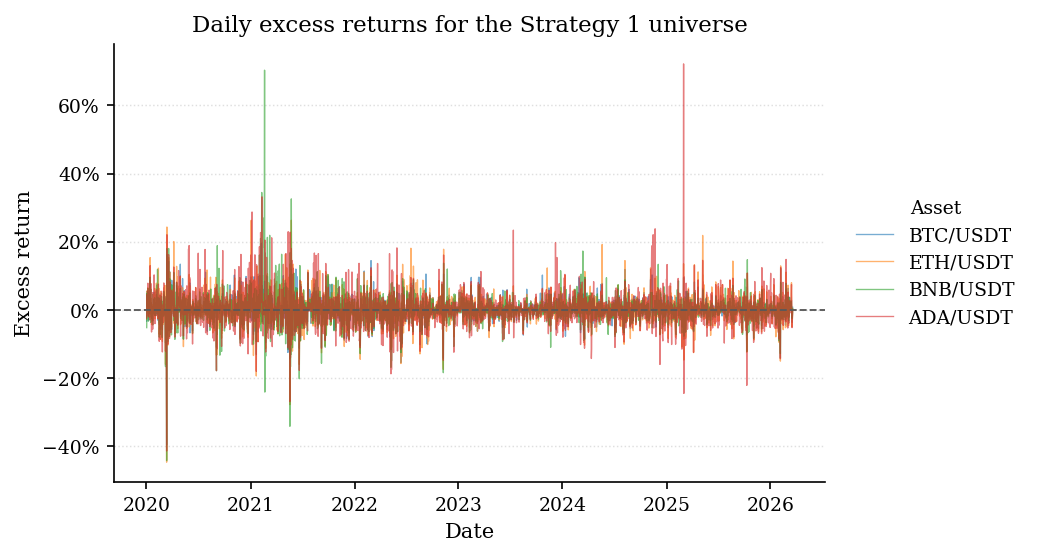

,mean,std,min,max
BTC/USDT,0.001464,0.032319,-0.395078,0.195359
ETH/USDT,0.002113,0.043330,-0.445999,0.263327
BNB/USDT,0.002600,0.044690,-0.441411,0.703020
ADA/USDT,0.002232,0.053569,-0.413232,0.721407


field                        close                            excess_return  \
asset                     ADA/USDT BNB/USDT BTC/USDT ETH/USDT      ADA/USDT   
timestamp                                                                     
2020-01-02 00:00:00+00:00  0.03269  13.0105  6965.71   127.19     -0.023638   
2020-01-03 00:00:00+00:00  0.03417  13.6474  7344.96   134.35      0.045232   
2020-01-04 00:00:00+00:00  0.03434  13.8092  7354.11   134.20      0.004933   
2020-01-05 00:00:00+00:00  0.03460  14.0532  7358.75   135.37      0.007529   
2020-01-06 00:00:00+00:00  0.03732  14.9471  7758.00   144.15      0.078571   

field                                                    
asset                      BNB/USDT  BTC/USDT  ETH/USDT  
timestamp                                                
2020-01-02 00:00:00+00:00 -0.051644 -0.032697 -0.027418  
2020-01-03 00:00:00+00:00  0.048911  0.054403  0.056252  
2020-01-04 00:00:00+00:00  0.011814  0.001204 -0.001159  
2020-01-05 00:00:00+00:00  0.017627  0.000589  0.008676  
2020-01-06 00:00:00+00:00  0.063566  0.054213  0.064817

In [11]:
rf_daily = ((1.0 + dff / 100.0) ** (1.0 / 365.0) - 1.0).rename('rf_daily')
rf_daily = rf_daily.reindex(pd.date_range(dff.index.min(), dff.index.max(), freq='D', tz='UTC')).ffill()

excess_returns = {}
for symbol in S1_SYMBOLS:
    asset = cleaned_frames[symbol].copy()
    asset['rf_daily'] = rf_daily.reindex(asset.index).ffill()
    asset['excess_return'] = asset['close'].pct_change() - asset['rf_daily']
    cleaned_frames[symbol] = asset
    excess_returns[symbol] = asset['excess_return'].rename(symbol)

excess_returns_df = pd.concat(excess_returns.values(), axis=1).dropna(how='all')

fig, ax = plt.subplots(figsize=(6.8, 3.6), constrained_layout=True)
colors = plt.get_cmap('tab10').colors
for i, col in enumerate(excess_returns_df.columns):
    ax.plot(excess_returns_df.index, excess_returns_df[col], linewidth=0.65, alpha=0.6, color=colors[i % len(colors)], label=col)
ax.axhline(0.0, color='0.35', linestyle='--', linewidth=0.9)
ax.set_title('Daily excess returns for the Strategy 1 universe')
ax.set_xlabel('Date')
ax.set_ylabel('Excess return')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.4)
ax.grid(False, axis='x')
ax.legend(title='Asset', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
maybe_save(fig, 'daily_excess_returns')
plt.show()

close_wide = pd.concat(
    [cleaned_frames[s]['close'] for s in S1_SYMBOLS],
    axis=1,
    keys=pd.MultiIndex.from_product([['close'], S1_SYMBOLS], names=['field', 'asset']),
)
excess_wide = pd.concat(
    [cleaned_frames[s]['excess_return'] for s in S1_SYMBOLS],
    axis=1,
    keys=pd.MultiIndex.from_product([['excess_return'], S1_SYMBOLS], names=['field', 'asset']),
)
asset_panel = pd.concat([close_wide, excess_wide], axis=1).sort_index(axis=1).dropna(how='any')

display(excess_returns_df.describe().T[['mean', 'std', 'min', 'max']])
display(asset_panel.head())


## Development Sample, Walk-Forward Folds, and Final Untouched Holdout

The final 126 daily bars are reserved as the only untouched signoff window. Everything else is used for walk-forward tuning on the development sample.


In [12]:
idx = asset_panel.index.sort_values()
n = len(idx)
HOLDOUT_FRAC_CONTAM = 0.225
FINAL_TEST_BARS = 126
INITIAL_TRAIN_BARS = 600
VAL_BARS = 100
STEP_BARS = 100
WF_MODE = 'expanding'
TRAIN_BARS = 600

if FINAL_TEST_BARS <= 0 or FINAL_TEST_BARS >= n:
    raise ValueError(f'FINAL_TEST_BARS must be in [1, n-1], got {FINAL_TEST_BARS} for n={n}')

legacy_holdout_n = max(1, int(round(HOLDOUT_FRAC_CONTAM * n)))
legacy_holdout_index = idx[-legacy_holdout_n:]
holdout_index = idx[-FINAL_TEST_BARS:]
dev_index = idx[:-FINAL_TEST_BARS]

if INITIAL_TRAIN_BARS + VAL_BARS > len(dev_index):
    raise ValueError('Development sample is too short for the requested fold geometry.')

fold_rows = []
val_start_pos = INITIAL_TRAIN_BARS
fold_id = 0
while val_start_pos + VAL_BARS <= len(dev_index):
    fold_id += 1
    val_ix = dev_index[val_start_pos: val_start_pos + VAL_BARS]
    if WF_MODE == 'expanding':
        train_ix = dev_index[:val_start_pos]
    else:
        train_ix = dev_index[val_start_pos - TRAIN_BARS: val_start_pos]
    fold_rows.append({
        'fold': fold_id,
        'train_start': train_ix.min(),
        'train_end': train_ix.max(),
        'train_bars': len(train_ix),
        'val_start': val_ix.min(),
        'val_end': val_ix.max(),
        'val_bars': len(val_ix),
    })
    val_start_pos += STEP_BARS

wf_folds = pd.DataFrame(fold_rows)
if wf_folds.empty:
    raise ValueError('No walk-forward folds were generated.')

sample_windows = pd.DataFrame([
    {'sample': 'Full sample', 'start': idx.min(), 'end': idx.max(), 'bars': len(idx)},
    {'sample': 'Historical contaminated holdout', 'start': legacy_holdout_index.min(), 'end': legacy_holdout_index.max(), 'bars': len(legacy_holdout_index)},
    {'sample': 'Development sample', 'start': dev_index.min(), 'end': dev_index.max(), 'bars': len(dev_index)},
    {'sample': 'Final untouched holdout', 'start': holdout_index.min(), 'end': holdout_index.max(), 'bars': len(holdout_index)},
])

display(sample_windows)
display(wf_folds)


,sample,start,end,bars
0,Full sample,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00,2270
1,Historical contaminated holdout,2024-10-26 00:00:00+00:00,2026-03-20 00:00:00+00:00,511
2,Development sample,2020-01-02 00:00:00+00:00,2025-11-14 00:00:00+00:00,2144
3,Final untouched holdout,2025-11-15 00:00:00+00:00,2026-03-20 00:00:00+00:00,126


,fold,train_start,train_end,train_bars,val_start,val_end,val_bars
0,1,2020-01-02 00:00:00+00:00,2021-08-23 00:00:00+00:00,600,2021-08-24 00:00:00+00:00,2021-12-01 00:00:00+00:00,100
1,2,2020-01-02 00:00:00+00:00,2021-12-01 00:00:00+00:00,700,2021-12-02 00:00:00+00:00,2022-03-11 00:00:00+00:00,100
2,3,2020-01-02 00:00:00+00:00,2022-03-11 00:00:00+00:00,800,2022-03-12 00:00:00+00:00,2022-06-19 00:00:00+00:00,100
3,4,2020-01-02 00:00:00+00:00,2022-06-19 00:00:00+00:00,900,2022-06-20 00:00:00+00:00,2022-09-27 00:00:00+00:00,100
4,5,2020-01-02 00:00:00+00:00,2022-09-27 00:00:00+00:00,1000,2022-09-28 00:00:00+00:00,2023-01-05 00:00:00+00:00,100
5,6,2020-01-02 00:00:00+00:00,2023-01-05 00:00:00+00:00,1100,2023-01-06 00:00:00+00:00,2023-04-15 00:00:00+00:00,100
6,7,2020-01-02 00:00:00+00:00,2023-04-15 00:00:00+00:00,1200,2023-04-16 00:00:00+00:00,2023-07-24 00:00:00+00:00,100
7,8,2020-01-02 00:00:00+00:00,2023-07-24 00:00:00+00:00,1300,2023-07-25 00:00:00+00:00,2023-11-01 00:00:00+00:00,100
8,9,2020-01-02 00:00:00+00:00,2023-11-01 00:00:00+00:00,1400,2023-11-02 00:00:00+00:00,2024-02-09 00:00:00+00:00,100
9,10,2020-01-02 00:00:00+00:00,2024-02-09 00:00:00+00:00,1500,2024-02-10 00:00:00+00:00,2024-05-19 00:00:00+00:00,100


## Strategy 1: Cross-Sectional Trend with Cost-Aware Holdout Evaluation

Signal construction follows the project logic:

- trend = distance from a rolling moving average,
- activation = threshold on the standardised trend score,
- sizing = one inverse-volatility step plus L1 normalisation,
- execution = one-bar lag and Abdi–Ranaldo transaction costs.

The plot below shows the baseline signal geometry used for visual diagnostics before walk-forward tuning.


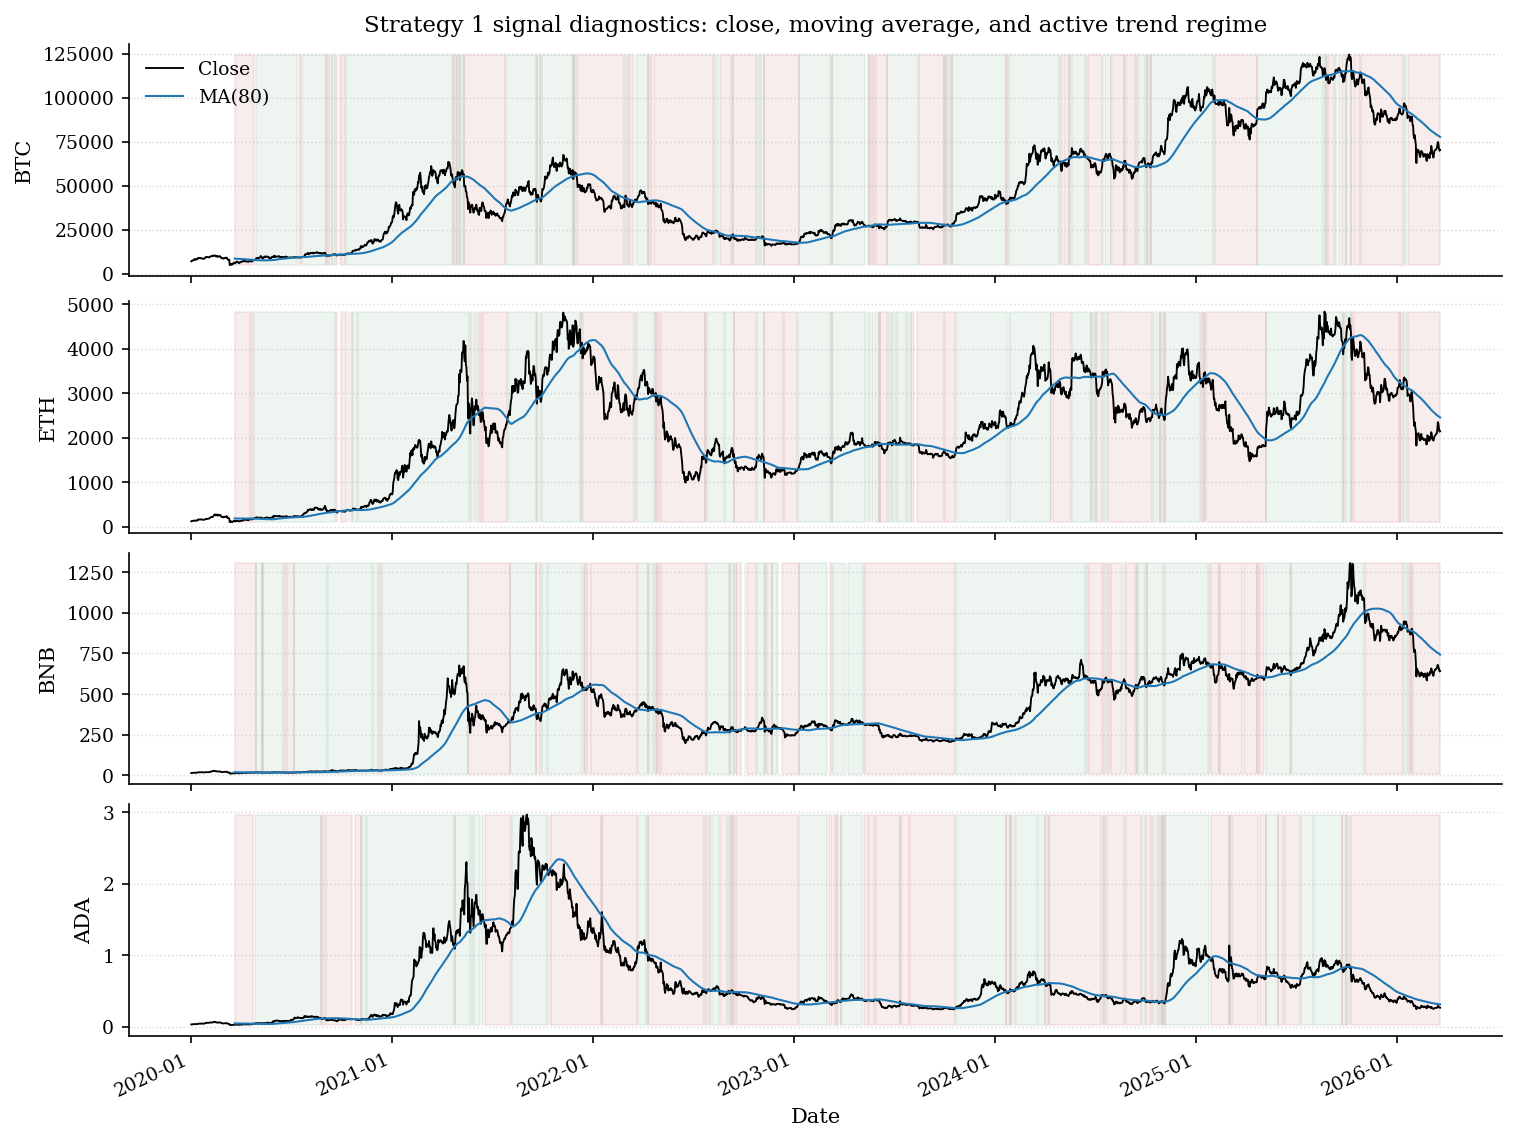

In [13]:
MA_WINDOW = 80
VOL_WINDOW = 30
DEAD_ZONE = 0.25
SIGNAL_CLIP = 5.0
GROSS_UTIL = 0.50

# MVO parameters
COV_WINDOW = 120   # Rolling window length for covariance estimation (bars)
GAMMA      = 1.0   # Risk-aversion scalar
USE_MVO    = True  # True → MVO weights;  False → original inverse-vol weights

close_px = asset_panel['close']
plot_rows = []
for symbol in S1_SYMBOLS:
    series = close_px[symbol]
    ma_series = series.rolling(MA_WINDOW, min_periods=MA_WINDOW).mean()
    trend_raw = series / ma_series - 1.0
    vol_series = series.pct_change().rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std(ddof=0).replace(0.0, np.nan)
    z_score = (trend_raw / vol_series).clip(-SIGNAL_CLIP, SIGNAL_CLIP)
    trend_position = pd.Series(
        np.where(z_score > DEAD_ZONE, 1.0, np.where(z_score < -DEAD_ZONE, -1.0, 0.0)),
        index=series.index,
        dtype=float,
    ).where(z_score.notna(), np.nan)
    plot_rows.append((symbol, series, ma_series, trend_position))

fig, axes = plt.subplots(len(S1_SYMBOLS), 1, figsize=(10, 7.5), sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (symbol, px, ma_series, pos_series) in zip(axes, plot_rows):
    ax.plot(px.index, px, color='black', linewidth=0.9, label='Close')
    ax.plot(ma_series.index, ma_series, color='tab:blue', linewidth=1.0, label=f'MA({MA_WINDOW})')
    active = pos_series.fillna(0.0)
    ax.fill_between(px.index, px.min(), px.max(), where=active.gt(0), color='seagreen', alpha=0.08)
    ax.fill_between(px.index, px.min(), px.max(), where=active.lt(0), color='firebrick', alpha=0.08)
    ax.set_ylabel(symbol.replace('/USDT', ''))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
    ax.grid(False, axis='x')
axes[0].set_title('Strategy 1 signal diagnostics: close, moving average, and active trend regime')
axes[0].legend(loc='upper left', frameon=False)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=25, ha='right')
maybe_save(fig, 'trend_signals_vs_price')
plt.show()


## Strategy 1 Walk-Forward Search

This search now runs on a narrower parameter set for speed, while explicitly guaranteeing inclusion of the previously strong candidate (`MA120 / VOL40 / deadzone 1.25 / rebalance 10 / gross util 0.10`).


,MA_WINDOW,VOL_WINDOW,DEAD_ZONE,rebalance_every,gross_util,gamma,mean_val_sharpe,std_val_sharpe,wf_score,positive_fold_share,traded_fold_share,mean_val_turnover,is_candidate,is_selected
0,140,30,1.00,10,0.1,1.0,0.463633,1.579088,0.305725,0.625,1.0,405.924755,True,True
1,140,40,1.25,10,0.2,1.0,0.474280,1.566541,0.317626,0.625,1.0,833.628156,True,False
2,140,30,1.25,10,0.2,1.0,0.473033,1.572183,0.315815,0.625,1.0,827.835148,True,False
3,140,30,1.00,10,0.2,1.0,0.469622,1.579653,0.311657,0.625,1.0,811.849510,True,False
4,140,40,1.25,10,0.1,1.0,0.468216,1.566073,0.311609,0.625,1.0,416.814078,True,False
5,140,30,1.25,10,0.1,1.0,0.466877,1.571544,0.309723,0.625,1.0,413.917574,True,False
6,120,30,1.25,10,0.2,1.0,0.435774,1.451306,0.290644,0.625,1.0,952.467971,True,False
7,140,40,1.00,10,0.2,1.0,0.446739,1.603685,0.286370,0.625,1.0,807.701082,True,False
8,120,30,1.25,10,0.1,1.0,0.428517,1.450030,0.283514,0.625,1.0,476.233985,True,False
9,140,40,1.00,10,0.1,1.0,0.440754,1.603239,0.280430,0.625,1.0,403.850541,True,False


Chosen (WF/candidate): MA=140, VOL=30, DEAD_ZONE=1.0, rebalance_every=10, gross_util=0.10, gamma=1.00 (MVO=off)
WF search runtime: 38.77s | candidates=24 | folds_used=8/15 | signal=0.18s, backtest=38.20s, metrics=0.39s


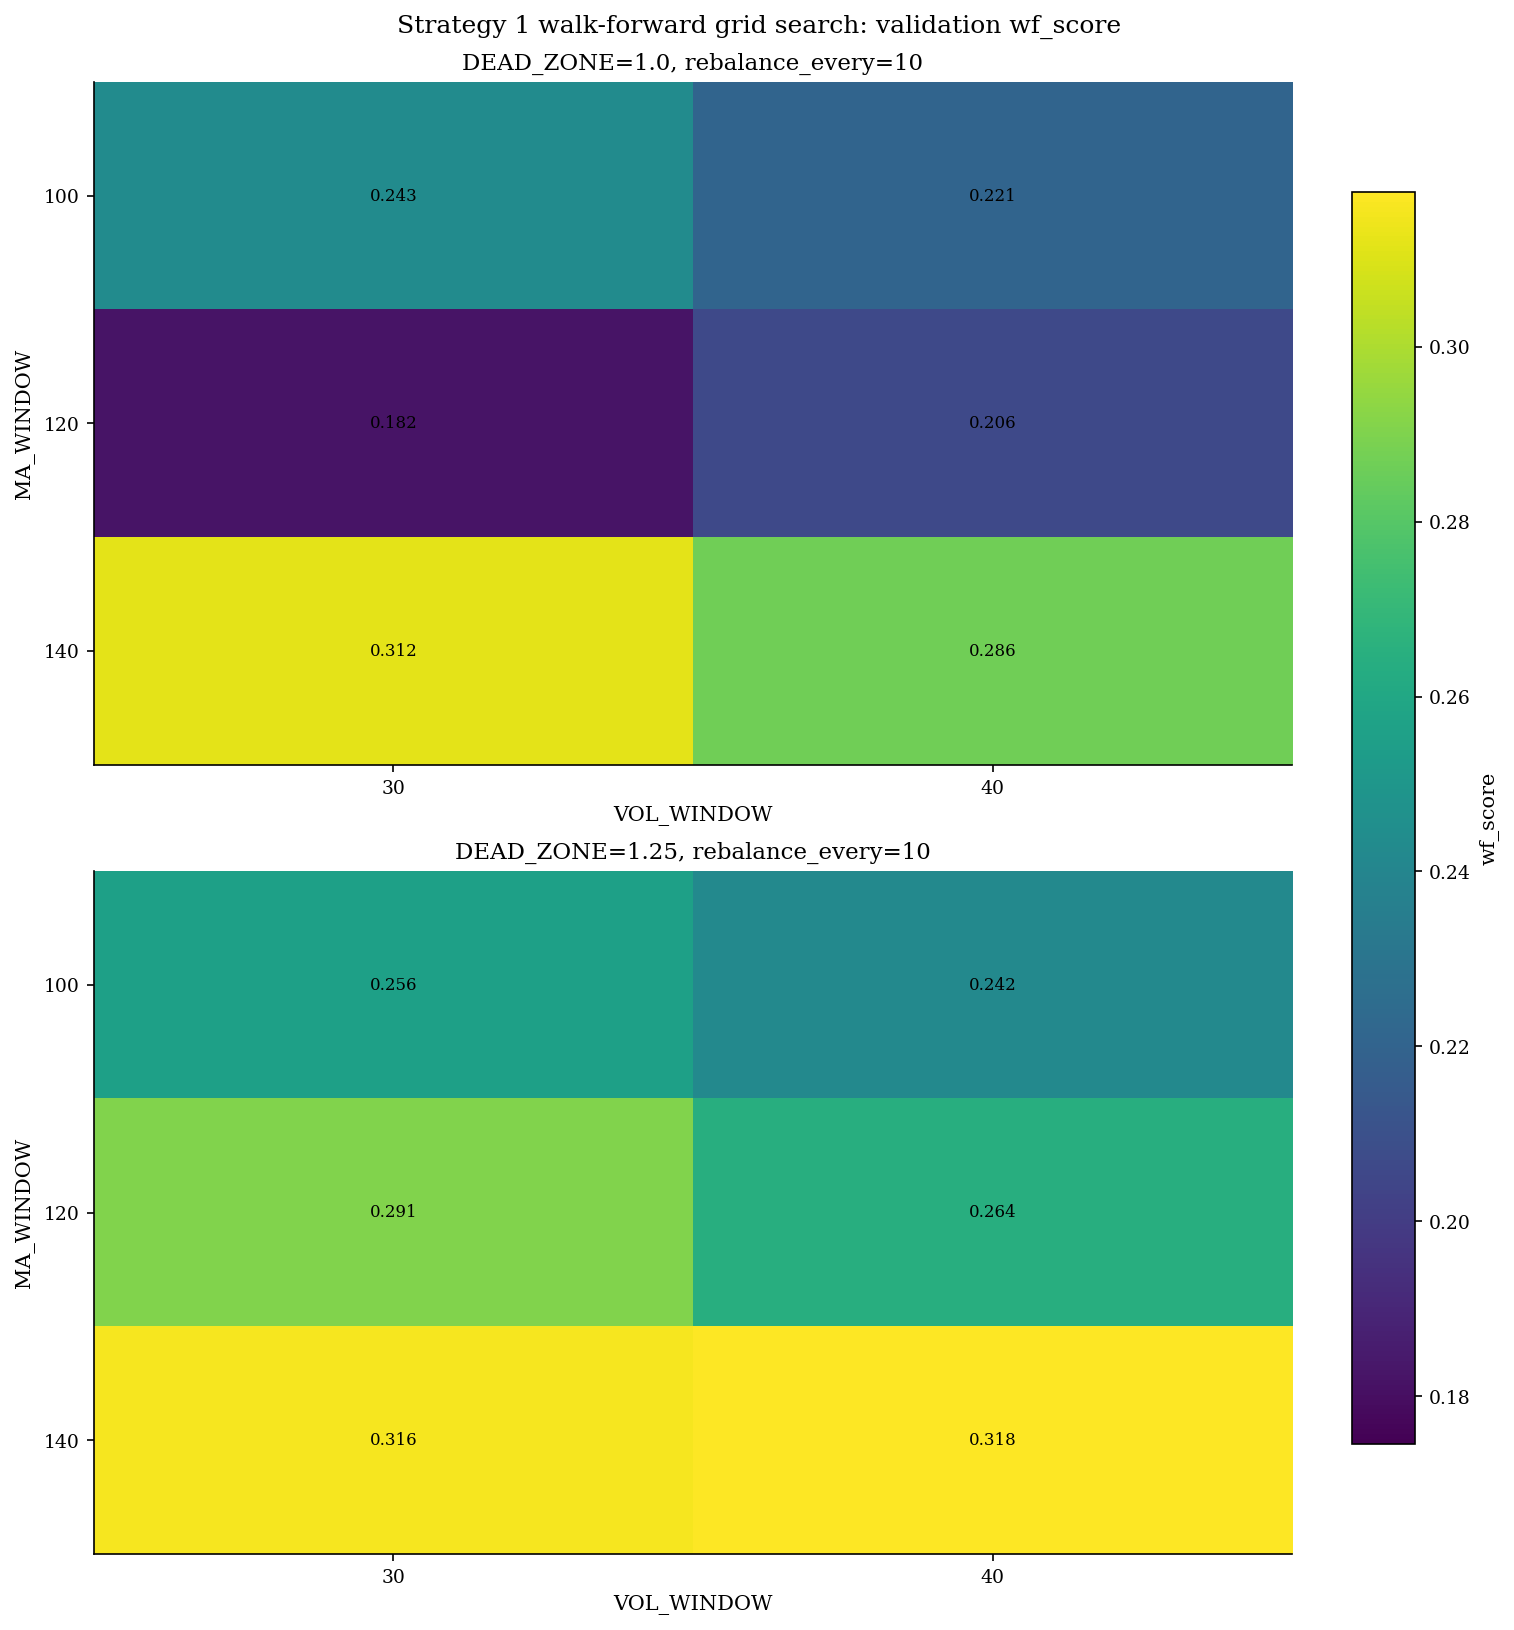

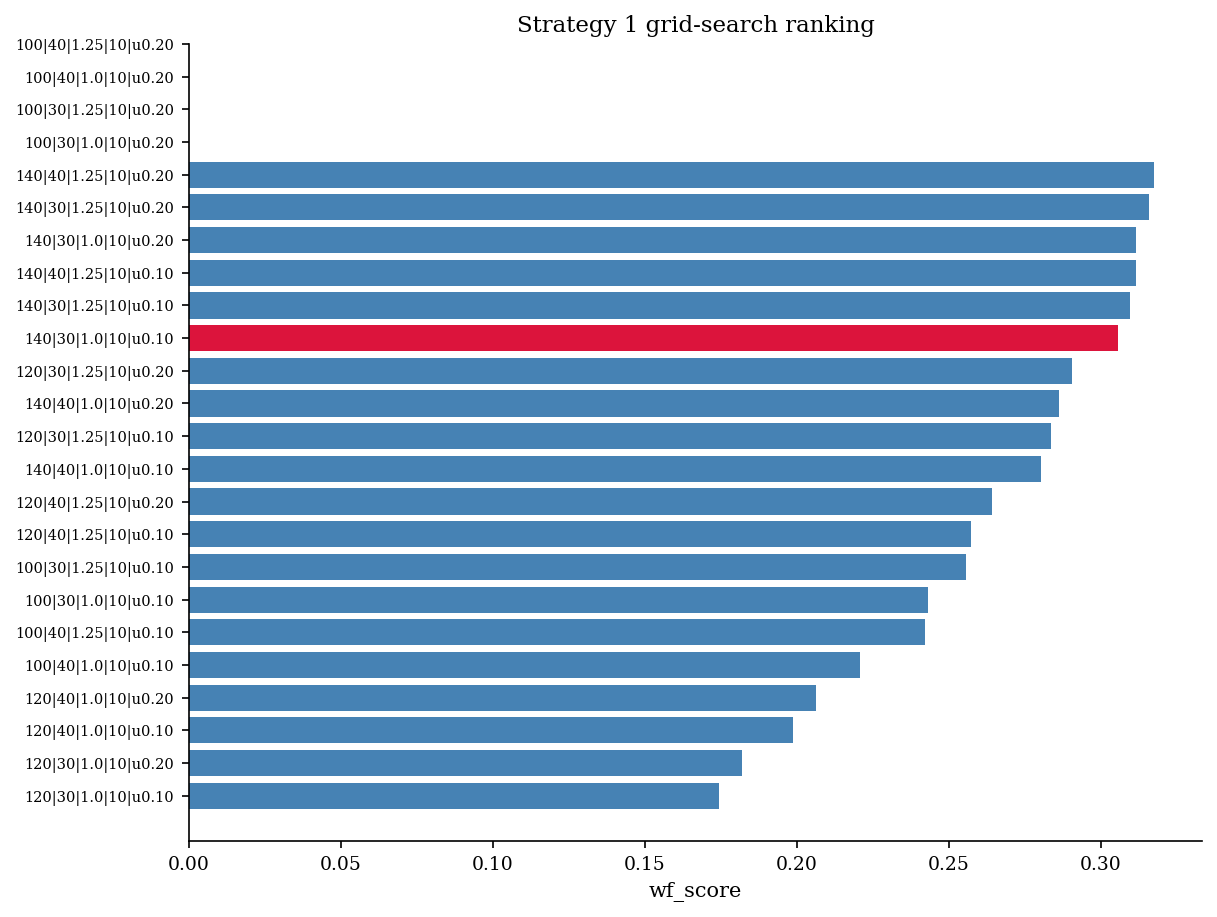

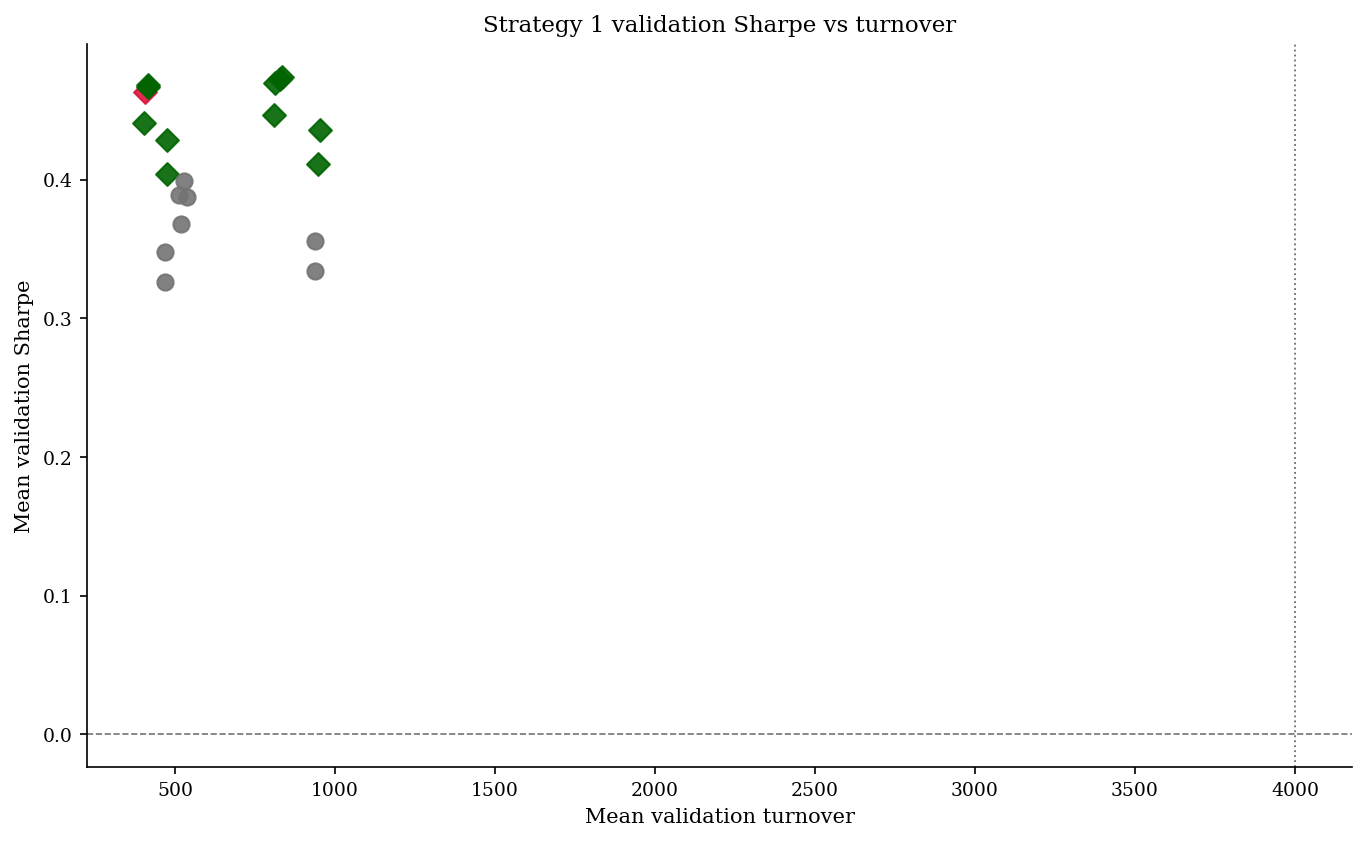

In [14]:
from time import perf_counter

STABILITY_PENALTY = 0.10
SIGNAL_CLIP_WF = 5.0
FAST_WF_SEARCH = True
FAST_WF_FOLD_STRIDE = 2
WF_SEARCH_USE_MVO = USE_MVO and (not FAST_WF_SEARCH)
WF_SEARCH_FAST_MODE = FAST_WF_SEARCH

# Reduced search space for faster WF tuning.
MA_GRID = [100, 120, 140]
VOL_GRID = [30, 40]
THRESH_GRID = [1.0, 1.25]
REBAL_GRID = [10]
UTIL_GRID = [0.10, 0.20]
GAMMA_GRID = [0.5, 1.0, 2.0] if WF_SEARCH_USE_MVO else [GAMMA]

MAX_MEAN_VAL_TURNOVER = 4_000.0
MIN_POSITIVE_FOLD_SHARE = 0.55
WF_TIE_BAND = 0.05
DEFAULT_WF = {
    'MA_WINDOW': 120,
    'VOL_WINDOW': 40,
    'DEAD_ZONE': 1.25,
    'rebalance_every': 10,
    'gross_util': 0.10,
}
INCLUDE_CANDIDATES = [
    {
        'MA_WINDOW': 120,
        'VOL_WINDOW': 40,
        'DEAD_ZONE': 1.25,
        'rebalance_every': 10,
        'gross_util': 0.10,
    },
]


def _nanmean_or_nan(values):
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    return float(np.mean(finite)) if len(finite) else np.nan


def _within_tie_band(series: pd.Series, best_value: float, tie_band: float) -> pd.Series:
    if not np.isfinite(best_value):
        return pd.Series(False, index=series.index)
    threshold = best_value - abs(best_value) * tie_band
    return series >= threshold


candidate_tuples = list(product(MA_GRID, VOL_GRID, THRESH_GRID, REBAL_GRID, UTIL_GRID, GAMMA_GRID))
for inc in INCLUDE_CANDIDATES:
    for gamma_wf in GAMMA_GRID:
        candidate_tuples.append((
            int(inc['MA_WINDOW']),
            int(inc['VOL_WINDOW']),
            float(inc['DEAD_ZONE']),
            int(inc['rebalance_every']),
            float(inc['gross_util']),
            float(gamma_wf),
        ))
all_candidates = list(dict.fromkeys(candidate_tuples))

wf_folds_eval = wf_folds
if FAST_WF_SEARCH:
    wf_folds_eval = wf_folds.iloc[::max(int(FAST_WF_FOLD_STRIDE), 1)].copy()
    if wf_folds_eval.empty:
        wf_folds_eval = wf_folds.tail(1).copy()

asset_panel_dev = asset_panel.loc[dev_index].copy()
half_spread_frac_dev = compute_half_spread_frac(asset_panel_dev, cleaned_frames, S1_SYMBOLS)
feature_cache = {}
wf_rows = []

t_start = perf_counter()
t_signal = 0.0
t_backtest = 0.0
t_metrics = 0.0

for ma_w, vol_w, dz, rebal, util, gamma_wf in all_candidates:
    t0 = perf_counter()
    theta_p = build_signal_and_theta(
        asset_panel_dev,
        S1_SYMBOLS,
        ma_window=ma_w,
        vol_window=vol_w,
        dead_zone=dz,
        signal_clip=SIGNAL_CLIP_WF,
        gross_cap=GROSS_CAP * util,
        rebalance_every=rebal,
        use_mvo=WF_SEARCH_USE_MVO,
        cov_window=COV_WINDOW,
        gamma=gamma_wf,
        feature_cache=feature_cache,
        search_fast_mode=WF_SEARCH_FAST_MODE,
    )
    t_signal += perf_counter() - t0

    t1 = perf_counter()
    out_p = run_net_backtest(
        asset_panel_dev,
        theta_p,
        S1_SYMBOLS,
        half_spread_frac_dev,
        backtest_use_excess=False,
        v0=V0,
    )
    t_backtest += perf_counter() - t1

    fold_sharpes, fold_rets, fold_dds, fold_tos, fold_cost_ratios, fold_active_days = [], [], [], [], [], []
    t2 = perf_counter()
    for _, row in wf_folds_eval.iterrows():
        val_ix = dev_index[(dev_index >= row['val_start']) & (dev_index <= row['val_end'])]
        metrics = metrics_on_window(
            out_p['net_portfolio_value'],
            out_p['turnover'],
            val_ix,
            trading_days=TRADING_DAYS,
            gross_pnl=out_p['gross_pnl'],
            cost_t=out_p['cost_t'],
            theta_exec=out_p['theta_exec'],
        )
        fold_sharpes.append(metrics['sharpe'])
        fold_rets.append(metrics['total_return'])
        fold_dds.append(metrics['max_dd'])
        fold_tos.append(metrics['mean_turnover'])
        fold_cost_ratios.append(metrics['cost_to_gross_ratio'])
        fold_active_days.append(metrics['active_days_pct'])
    t_metrics += perf_counter() - t2

    fs = np.asarray(fold_sharpes, dtype=float)
    finite_fs = fs[np.isfinite(fs)]
    mean_s = float(np.mean(finite_fs)) if len(finite_fs) else np.nan
    std_s = float(np.std(finite_fs, ddof=1)) if len(finite_fs) > 1 else 0.0
    wf_score = mean_s - STABILITY_PENALTY * std_s if np.isfinite(mean_s) else np.nan
    positive_fold_share = float(np.mean(np.isfinite(fs) & (fs > 0))) if len(fs) else 0.0
    traded_fold_share = float(np.mean(np.asarray(fold_active_days, dtype=float) > 0)) if len(fold_active_days) else 0.0
    mean_turnover = _nanmean_or_nan(fold_tos)
    is_candidate = bool(
        np.isfinite(mean_s)
        and mean_s > 0
        and positive_fold_share >= MIN_POSITIVE_FOLD_SHARE
        and np.isfinite(mean_turnover)
        and mean_turnover <= MAX_MEAN_VAL_TURNOVER
    )
    wf_rows.append({
        'MA_WINDOW': ma_w,
        'VOL_WINDOW': vol_w,
        'DEAD_ZONE': dz,
        'rebalance_every': rebal,
        'gross_util': util,
        'mean_val_sharpe': mean_s,
        'std_val_sharpe': std_s,
        'wf_score': wf_score,
        'mean_val_return': _nanmean_or_nan(fold_rets),
        'mean_val_max_dd': _nanmean_or_nan(fold_dds),
        'mean_val_turnover': mean_turnover,
        'mean_val_cost_to_gross': _nanmean_or_nan(fold_cost_ratios),
        'positive_fold_share': positive_fold_share,
        'traded_fold_share': traded_fold_share,
        'gamma': gamma_wf,
        'active_days_pct': _nanmean_or_nan(fold_active_days),
        'is_candidate': is_candidate,
    })

elapsed_total = perf_counter() - t_start
wf_search_df = pd.DataFrame(wf_rows)
candidates = wf_search_df[wf_search_df['is_candidate']].copy()
if not candidates.empty:
    best_score = float(candidates['wf_score'].max())
    finalists = candidates[_within_tie_band(candidates['wf_score'], best_score, WF_TIE_BAND)].copy()
    finalists['abs_mean_val_max_dd'] = finalists['mean_val_max_dd'].abs()
    best = finalists.sort_values(
        ['mean_val_turnover', 'mean_val_return', 'abs_mean_val_max_dd'],
        ascending=[True, False, True],
    ).iloc[0]
    selection_mode = 'candidate'
else:
    fallback_mask = (
        (wf_search_df['MA_WINDOW'] == DEFAULT_WF['MA_WINDOW'])
        & (wf_search_df['VOL_WINDOW'] == DEFAULT_WF['VOL_WINDOW'])
        & (wf_search_df['DEAD_ZONE'] == DEFAULT_WF['DEAD_ZONE'])
        & (wf_search_df['rebalance_every'] == DEFAULT_WF['rebalance_every'])
        & (wf_search_df['gross_util'] == DEFAULT_WF['gross_util'])
    )
    if fallback_mask.any():
        best = wf_search_df.loc[fallback_mask].iloc[0]
        selection_mode = 'default_fallback'
    else:
        best = wf_search_df.sort_values(
            ['wf_score', 'mean_val_turnover', 'mean_val_return', 'mean_val_max_dd'],
            ascending=[False, True, False, False],
        ).iloc[0]
        selection_mode = 'best_available_fallback'

wf_search_df['is_selected'] = False
wf_search_df.loc[best.name, 'is_selected'] = True
wf_search_df = wf_search_df.sort_values(
    ['is_selected', 'is_candidate', 'wf_score', 'mean_val_turnover', 'mean_val_return'],
    ascending=[False, False, False, True, False],
).reset_index(drop=True)

strategy1_selected_params = {
    'MA_WINDOW': int(best['MA_WINDOW']),
    'VOL_WINDOW': int(best['VOL_WINDOW']),
    'DEAD_ZONE': float(best['DEAD_ZONE']),
    'rebalance_every': int(best['rebalance_every']),
    'gross_util': float(best['gross_util']),
    'gamma': float(best['gamma']),
}

display(
    wf_search_df[
        ['MA_WINDOW', 'VOL_WINDOW', 'DEAD_ZONE', 'rebalance_every', 'gross_util', 'gamma',
         'mean_val_sharpe', 'std_val_sharpe', 'wf_score', 'positive_fold_share',
         'traded_fold_share', 'mean_val_turnover', 'is_candidate', 'is_selected']
    ].head(12)
)
print(
    f"Chosen (WF/{selection_mode}): MA={strategy1_selected_params['MA_WINDOW']}, "
    f"VOL={strategy1_selected_params['VOL_WINDOW']}, DEAD_ZONE={strategy1_selected_params['DEAD_ZONE']}, "
    f"rebalance_every={strategy1_selected_params['rebalance_every']}, gross_util={strategy1_selected_params['gross_util']:.2f}, "
    f"gamma={strategy1_selected_params['gamma']:.2f} (MVO={'on' if WF_SEARCH_USE_MVO else 'off'})"
)
print(
    f"WF search runtime: {elapsed_total:.2f}s | candidates={len(all_candidates)} | "
    f"folds_used={len(wf_folds_eval)}/{len(wf_folds)} | "
    f"signal={t_signal:.2f}s, backtest={t_backtest:.2f}s, metrics={t_metrics:.2f}s"
)

from matplotlib.colors import Normalize

vmin = float(wf_search_df['wf_score'].min())
vmax = float(wf_search_df['wf_score'].max())
norm = Normalize(vmin=vmin, vmax=vmax)
fig_hm, axes_hm = plt.subplots(len(THRESH_GRID), len(REBAL_GRID), figsize=(10, 10.5), constrained_layout=True)
axes_hm = np.asarray(axes_hm).reshape(len(THRESH_GRID), len(REBAL_GRID))
for plot_idx, (dz, rebal) in enumerate(product(THRESH_GRID, REBAL_GRID)):
    row = plot_idx // len(REBAL_GRID)
    col = plot_idx % len(REBAL_GRID)
    ax = axes_hm[row, col]
    sub = wf_search_df[(wf_search_df['DEAD_ZONE'] == dz) & (wf_search_df['rebalance_every'] == rebal)]
    pivot = sub.pivot_table(index='MA_WINDOW', columns='VOL_WINDOW', values='wf_score', aggfunc='max')
    pivot = pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', norm=norm)
    ax.set_xticks(np.arange(pivot.shape[1]), [str(v) for v in pivot.columns])
    ax.set_yticks(np.arange(pivot.shape[0]), [str(v) for v in pivot.index])
    ax.set_title(f'DEAD_ZONE={dz}, rebalance_every={rebal}')
    ax.set_xlabel('VOL_WINDOW')
    ax.set_ylabel('MA_WINDOW')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8)
fig_hm.colorbar(im, ax=axes_hm, shrink=0.85, label='wf_score')
fig_hm.suptitle('Strategy 1 walk-forward grid search: validation wf_score', y=1.02, fontsize=12)
maybe_save(fig_hm, 'wf_grid_search_heatmaps')
plt.show()

wf_sorted = wf_search_df.sort_values('wf_score', ascending=True).copy()
labels = [
    f"{int(r.MA_WINDOW)}|{int(r.VOL_WINDOW)}|{r.DEAD_ZONE}|{int(r.rebalance_every)}|u{r.gross_util:.2f}"
    for _, r in wf_sorted.iterrows()
]
colors = ['crimson' if selected else 'steelblue' for selected in wf_sorted['is_selected']]
fig_bar, ax_bar = plt.subplots(figsize=(8, max(6.0, 0.20 * len(wf_sorted))), constrained_layout=True)
ax_bar.barh(np.arange(len(wf_sorted)), wf_sorted['wf_score'], color=colors)
ax_bar.set_yticks(np.arange(len(wf_sorted)), labels, fontsize=7)
ax_bar.set_xlabel('wf_score')
ax_bar.set_title('Strategy 1 grid-search ranking')
maybe_save(fig_bar, 'wf_grid_search_ranking')
plt.show()

fig_scatter, ax_scatter = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
for _, row in wf_search_df.iterrows():
    color = 'crimson' if row['is_selected'] else ('darkgreen' if row['is_candidate'] else '0.45')
    marker = 'D' if row['is_candidate'] else 'o'
    ax_scatter.scatter(row['mean_val_turnover'], row['mean_val_sharpe'], color=color, marker=marker, s=60, alpha=0.9)
ax_scatter.axhline(0.0, color='0.45', linestyle='--', linewidth=0.8)
ax_scatter.axvline(MAX_MEAN_VAL_TURNOVER, color='0.45', linestyle=':', linewidth=0.9)
ax_scatter.set_xlabel('Mean validation turnover')
ax_scatter.set_ylabel('Mean validation Sharpe')
ax_scatter.set_title('Strategy 1 validation Sharpe vs turnover')
maybe_save(fig_scatter, 'wf_validation_sharpe_vs_turnover')
plt.show()


## Strategy 1 Final Holdout Comparison

The final untouched holdout compares the walk-forward-selected specification against the historical baseline.

The comparison table below is **liquidation-aware**: if a model has already been wiped out before holdout start, that is surfaced explicitly rather than being reported as a benign flat holdout series.


,n_days,holdout_start_equity,liquidated_at,liquidated_before_holdout,sharpe,sortino,calmar,max_drawdown,mean_turnover,total_gross_pnl,total_cost,total_net_pnl,pct_return_on_v0,cost_to_gross_ratio,final_net_equity,active_days_pct,comparison_outcome
model,,,,,,,,,,,,,,,,,
Baseline 40/15/0.5/2,126,-11418.512248,2020-02-25 00:00:00+00:00,True,NaN,NaN,NaN,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-11418.512248,0.0,selected_beats
Selected WF model,126,41902.790114,NaN,False,1.300222,1.837517,3.323954,-0.037758,107.162954,2511.389896,80.030679,2431.359217,0.243136,0.003568,44433.785512,1.0,selected_beats


Baseline 40/15/0.5/2                                     \
                        gross cost  net avg_abs_pos avg_turnover   
BTC/USDT                  0.0  0.0  0.0         0.0          0.0   
ETH/USDT                  0.0  0.0  0.0         0.0          0.0   
BNB/USDT                  0.0  0.0  0.0         0.0          0.0   
ADA/USDT                  0.0  0.0  0.0         0.0          0.0   

         Selected WF model                                                    
                     gross       cost          net  avg_abs_pos avg_turnover  
BTC/USDT       2512.212283  49.128004  2463.084279  8455.138540    60.673196  
ETH/USDT          0.021722   0.005492     0.016230     0.073368     0.006008  
BNB/USDT         -0.855338  30.892246   -31.747585  1424.144138    46.477032  
ADA/USDT          0.011230   0.004937     0.006292     0.074306     0.006718

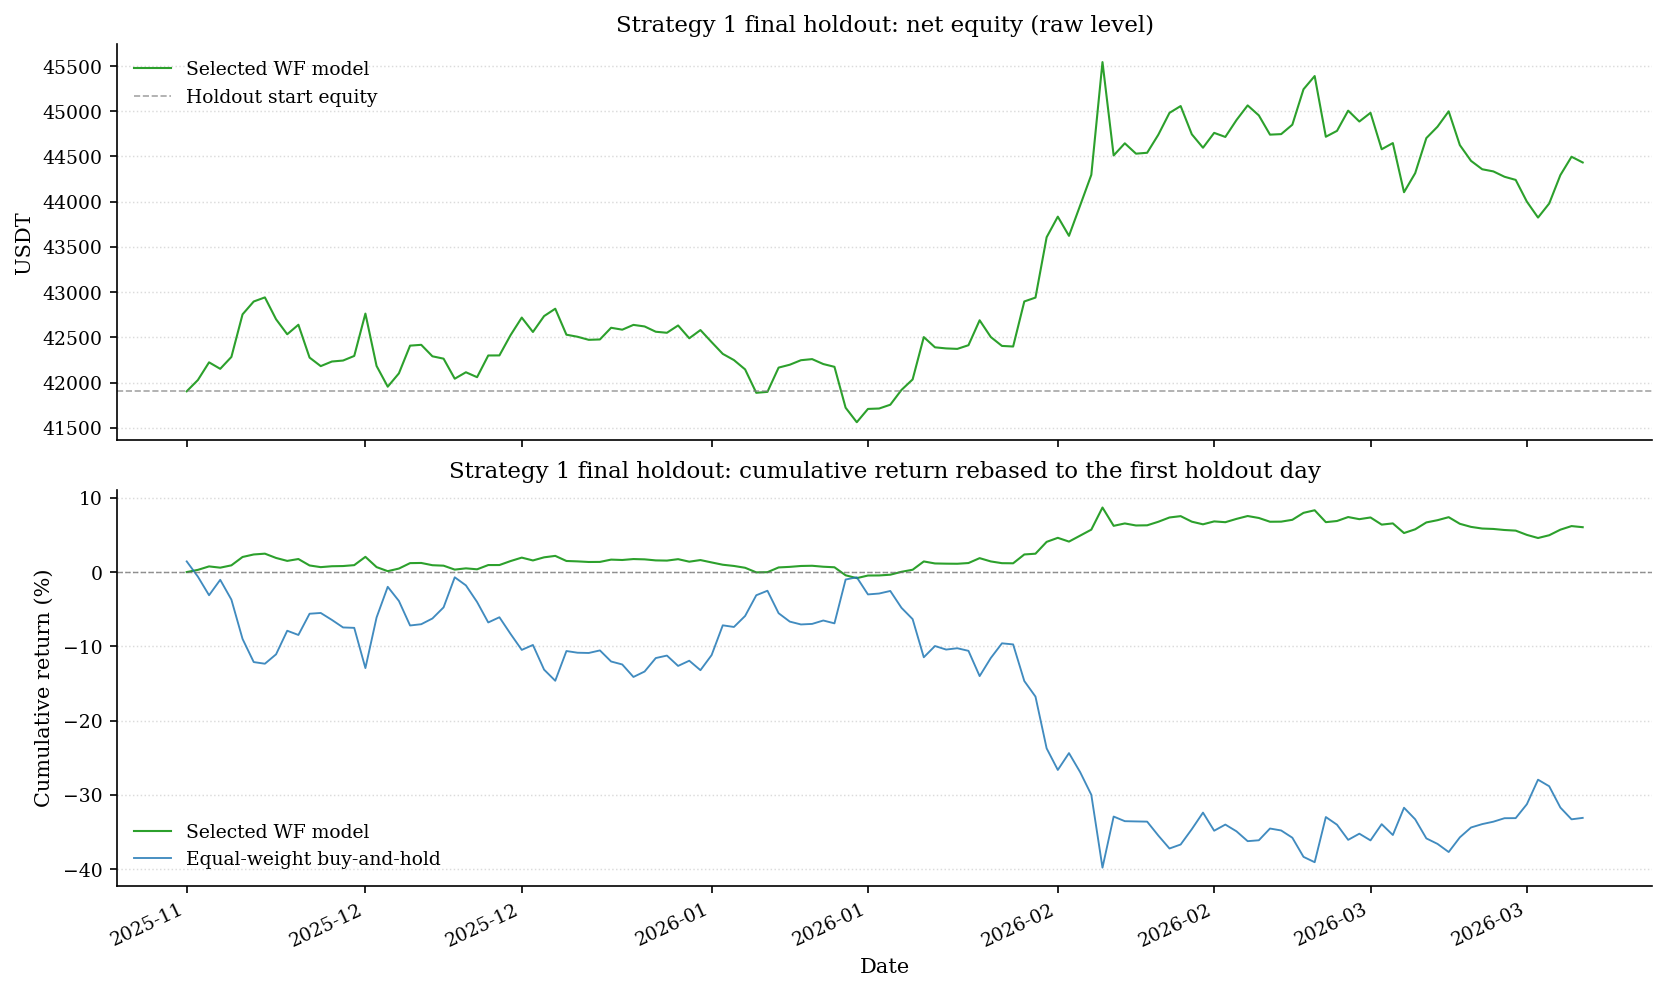

In [15]:
BASELINE_S1_PARAMS = {
    'MA_WINDOW': 40,
    'VOL_WINDOW': 15,
    'DEAD_ZONE': 0.5,
    'rebalance_every': 2,
    'gross_util': 1.0,
}

half_spread_frac_full = compute_half_spread_frac(asset_panel, cleaned_frames, S1_SYMBOLS)


def evaluate_s1_model(
    label: str,
    params: dict,
    print_diagnostic: bool = False,
    use_mvo: bool = USE_MVO,
    cov_window: int = COV_WINDOW,
) -> dict:
    theta = build_signal_and_theta(
        asset_panel,
        S1_SYMBOLS,
        ma_window=int(params['MA_WINDOW']),
        vol_window=int(params['VOL_WINDOW']),
        dead_zone=float(params['DEAD_ZONE']),
        signal_clip=SIGNAL_CLIP_WF,
        gross_cap=GROSS_CAP * float(params['gross_util']),
        rebalance_every=int(params['rebalance_every']),
        use_mvo=use_mvo,
        cov_window=cov_window,
        gamma=float(params.get('gamma', GAMMA)),
    )
    out = run_net_backtest(
        asset_panel,
        theta,
        S1_SYMBOLS,
        half_spread_frac_full,
        backtest_use_excess=False,
        v0=V0,
        print_diagnostic=print_diagnostic,
        diagnostic_window=6,
    )
    summary = summarize_holdout_model(label, out, holdout_index, trading_days=TRADING_DAYS, initial_capital=V0)
    asset_gross = out['theta_exec'].shift(1).fillna(0.0) * out['r']
    asset_cost = out['delta_theta_exec'].abs() * half_spread_frac_full.reindex(out['r'].index).fillna(0.0)
    asset_net = asset_gross - asset_cost
    asset_breakdown = pd.DataFrame({
        'gross': asset_gross.loc[holdout_index].sum(),
        'cost': asset_cost.loc[holdout_index].sum(),
        'net': asset_net.loc[holdout_index].sum(),
        'avg_abs_pos': out['theta_exec'].loc[holdout_index].abs().mean(),
        'avg_turnover': out['delta_theta_exec'].loc[holdout_index].abs().mean(),
    })
    return {'out': out, 'summary': summary, 'asset_breakdown': asset_breakdown}


def decide_holdout_outcome(selected: dict, baseline: dict) -> str:
    if selected['liquidated_before_holdout'] and not baseline['liquidated_before_holdout']:
        return 'baseline_beats'
    if baseline['liquidated_before_holdout'] and not selected['liquidated_before_holdout']:
        return 'selected_beats'

    selected_wins = (
        np.isfinite(selected['sharpe']) and np.isfinite(baseline['sharpe']) and selected['sharpe'] > baseline['sharpe']
        and np.isfinite(selected['total_net_pnl']) and np.isfinite(baseline['total_net_pnl']) and selected['total_net_pnl'] > baseline['total_net_pnl']
        and np.isfinite(selected['cost_to_gross_ratio']) and np.isfinite(baseline['cost_to_gross_ratio']) and selected['cost_to_gross_ratio'] < baseline['cost_to_gross_ratio']
    )
    baseline_wins = (
        np.isfinite(selected['sharpe']) and np.isfinite(baseline['sharpe']) and baseline['sharpe'] > selected['sharpe']
        and np.isfinite(selected['total_net_pnl']) and np.isfinite(baseline['total_net_pnl']) and baseline['total_net_pnl'] > selected['total_net_pnl']
        and np.isfinite(selected['cost_to_gross_ratio']) and np.isfinite(baseline['cost_to_gross_ratio']) and baseline['cost_to_gross_ratio'] < selected['cost_to_gross_ratio']
    )
    if selected_wins:
        return 'selected_beats'
    if baseline_wins:
        return 'baseline_beats'
    return 'inconclusive'


selected_model = evaluate_s1_model('Selected WF model', strategy1_selected_params, print_diagnostic=False)
baseline_model = evaluate_s1_model('Baseline 40/15/0.5/2', BASELINE_S1_PARAMS, use_mvo=False)
strategy1_holdout_outcome = decide_holdout_outcome(selected_model['summary'], baseline_model['summary'])

comparison_df = pd.DataFrame([baseline_model['summary'], selected_model['summary']]).set_index('model')
comparison_df['comparison_outcome'] = strategy1_holdout_outcome

oos_asset_breakdown = pd.concat(
    {
        'Baseline 40/15/0.5/2': baseline_model['asset_breakdown'],
        'Selected WF model': selected_model['asset_breakdown'],
    },
    axis=1,
)

display(comparison_df)
display(oos_asset_breakdown)

selected_out = selected_model['out']
eq_oos = selected_out['net_portfolio_value'].reindex(holdout_index).dropna()
if len(eq_oos) >= 2 and eq_oos.iloc[0] > 0:
    cum_ret_oos = eq_oos / eq_oos.iloc[0] - 1.0
    r_h = asset_panel['close'].pct_change().reindex(holdout_index).dropna(how='any')
    ew_daily = r_h.mean(axis=1).reindex(eq_oos.index).fillna(0.0)
    cum_ew_bh = (1.0 + ew_daily).cumprod() - 1.0

    fig_oos, axes_oos = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, constrained_layout=True)
    axes_oos[0].plot(eq_oos.index, eq_oos, color='tab:green', linewidth=1.0, label='Selected WF model')
    axes_oos[0].axhline(eq_oos.iloc[0], color='0.5', linestyle='--', linewidth=0.8, alpha=0.7, label='Holdout start equity')
    axes_oos[0].set_ylabel('USDT')
    axes_oos[0].set_title('Strategy 1 final holdout: net equity (raw level)')
    axes_oos[0].legend(loc='best', frameon=False)
    axes_oos[0].grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)

    axes_oos[1].plot(cum_ret_oos.index, cum_ret_oos * 100.0, color='tab:green', linewidth=1.0, label='Selected WF model')
    axes_oos[1].plot(cum_ew_bh.index, cum_ew_bh * 100.0, color='tab:blue', linewidth=0.9, alpha=0.85, label='Equal-weight buy-and-hold')
    axes_oos[1].axhline(0.0, color='0.4', linewidth=0.7, linestyle='--', alpha=0.7)
    axes_oos[1].set_ylabel('Cumulative return (%)')
    axes_oos[1].set_xlabel('Date')
    axes_oos[1].set_title('Strategy 1 final holdout: cumulative return rebased to the first holdout day')
    axes_oos[1].legend(loc='best', frameon=False)
    axes_oos[1].grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
    axes_oos[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes_oos[1].xaxis.get_majorticklabels(), rotation=25, ha='right')
    maybe_save(fig_oos, 'oos_performance')
    plt.show()
else:
    print('Strategy 1 OOS plot skipped because the selected model has no positive equity at holdout start.')


In [16]:
# ── In-sample comparison: inverse-vol vs MVO ──────────────────────────────────
# Run the walk-forward-selected params with each weighting method over dev_index.

_cmp_params = dict(strategy1_selected_params)   # copy to avoid mutation

_theta_invvol = build_signal_and_theta(
    asset_panel_dev, S1_SYMBOLS,
    ma_window=int(_cmp_params['MA_WINDOW']),
    vol_window=int(_cmp_params['VOL_WINDOW']),
    dead_zone=float(_cmp_params['DEAD_ZONE']),
    signal_clip=SIGNAL_CLIP_WF,
    gross_cap=GROSS_CAP * float(_cmp_params['gross_util']),
    rebalance_every=int(_cmp_params['rebalance_every']),
    use_mvo=False,
)
_out_invvol = run_net_backtest(
    asset_panel_dev, _theta_invvol, S1_SYMBOLS,
    half_spread_frac_dev, backtest_use_excess=False, v0=V0,
)

_theta_mvo = build_signal_and_theta(
    asset_panel_dev, S1_SYMBOLS,
    ma_window=int(_cmp_params['MA_WINDOW']),
    vol_window=int(_cmp_params['VOL_WINDOW']),
    dead_zone=float(_cmp_params['DEAD_ZONE']),
    signal_clip=SIGNAL_CLIP_WF,
    gross_cap=GROSS_CAP * float(_cmp_params['gross_util']),
    rebalance_every=int(_cmp_params['rebalance_every']),
    use_mvo=True,
    cov_window=COV_WINDOW,
    gamma=float(_cmp_params.get('gamma', GAMMA)),
)
_out_mvo = run_net_backtest(
    asset_panel_dev, _theta_mvo, S1_SYMBOLS,
    half_spread_frac_dev, backtest_use_excess=False, v0=V0,
)


def _quick_metrics(out, window):
    eq = out['net_portfolio_value'].reindex(window).dropna()
    r  = eq.pct_change().dropna()
    to = out['turnover'].reindex(window).dropna()
    return {
        'Sharpe':        sharpe_ratio(r, TRADING_DAYS),
        'Max Drawdown':  max_drawdown(eq),
        'Mean Turnover': float(to.mean()) if len(to) else np.nan,
    }


_cmp_rows = {
    'Inverse-vol': _quick_metrics(_out_invvol, dev_index),
    'MVO':         _quick_metrics(_out_mvo,    dev_index),
}
_cmp_table = pd.DataFrame(_cmp_rows).T
_cmp_table['Max Drawdown'] = _cmp_table['Max Drawdown'].map('{:.2%}'.format)
_cmp_table['Sharpe']       = _cmp_table['Sharpe'].map('{:.3f}'.format)
_cmp_table['Mean Turnover']= _cmp_table['Mean Turnover'].map('${:,.0f}'.format)

print('Strategy 1 in-sample comparison: inverse-vol vs MVO')
display(_cmp_table)


Strategy 1 in-sample comparison: inverse-vol vs MVO


,Sharpe,Max Drawdown,Mean Turnover
Inverse-vol,1.226,-18.38%,$376
MVO,0.923,-22.28%,$585


## Strategy 1 In-Sample Performance Analysis

The holdout comparison above is the final signoff test, but it does not show how the selected walk-forward specification behaved across the full **development sample** used for model search. This section benchmarks the selected Strategy 1 model against the historical baseline and an equal-weight buy-and-hold basket of the Strategy 1 universe.


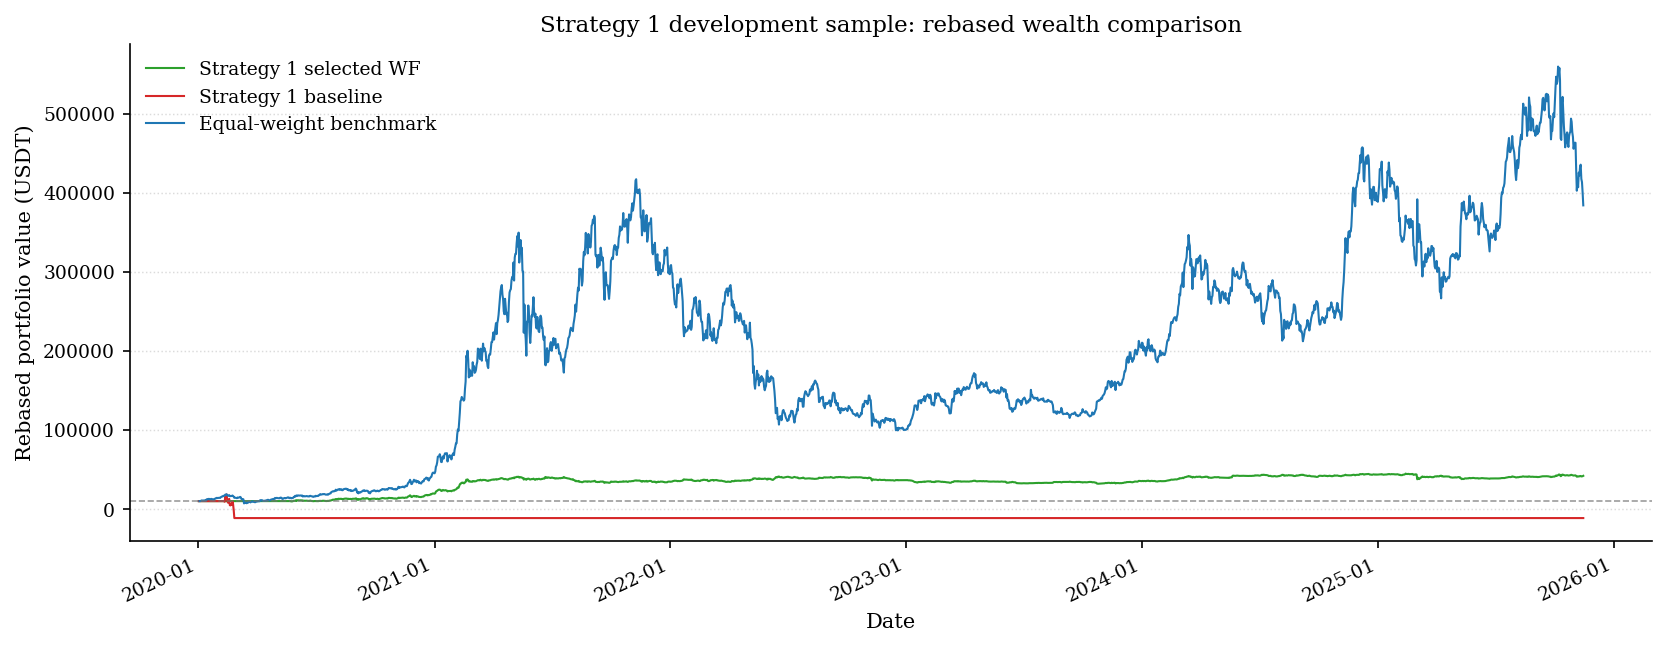

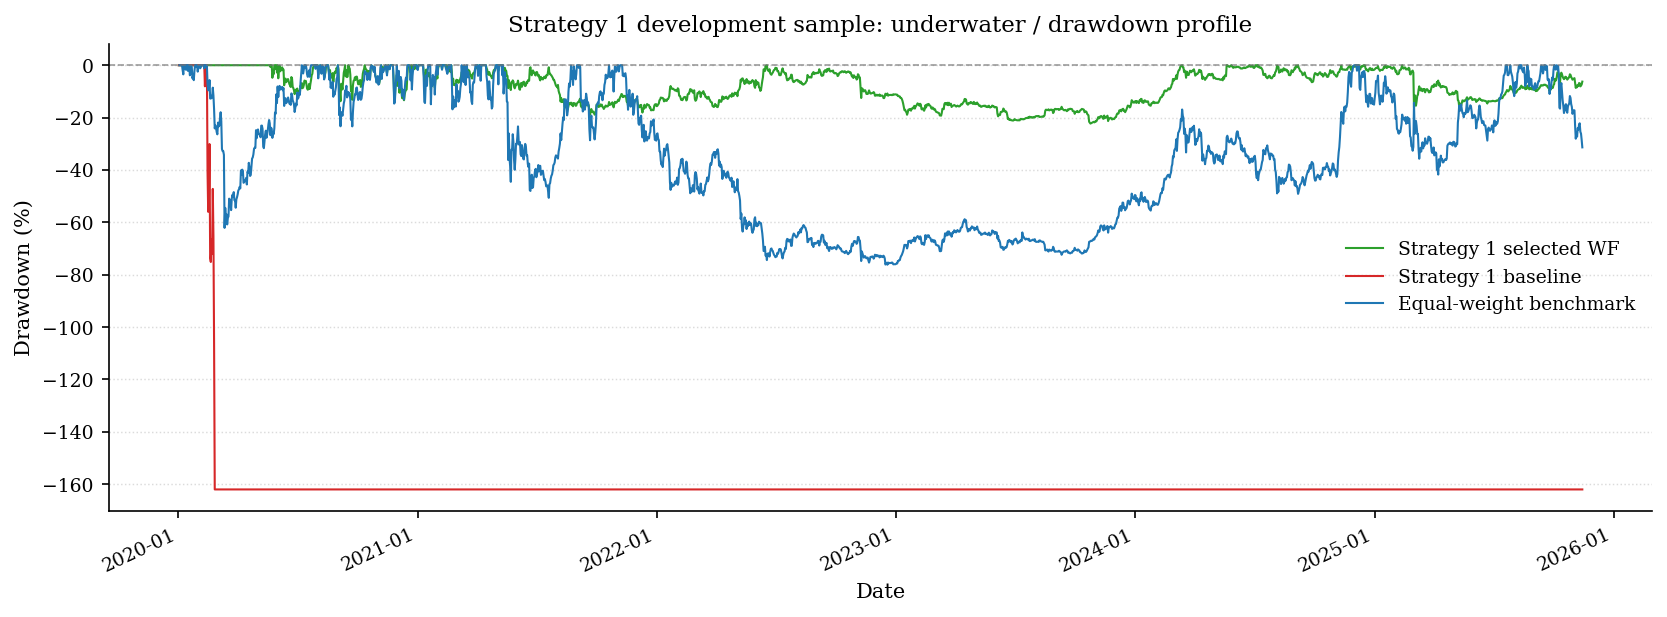

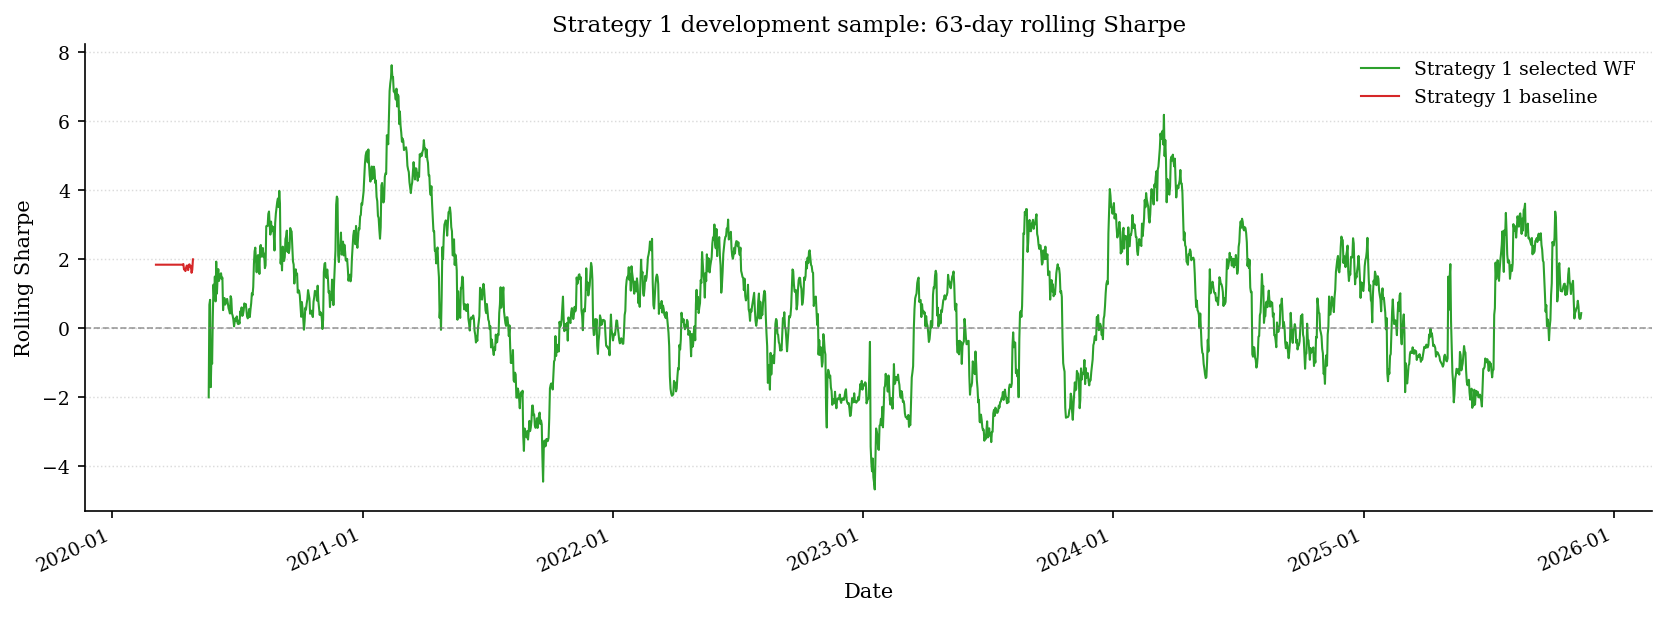

,total_return,ann_return,sharpe,sortino,calmar,max_drawdown,mean_turnover,cost_to_gross_ratio,active_days_pct,final_rebased_value,trade_entries,active_days,cost_drag,hit_rate
sample,,,,,,,,,,,,,,
Strategy 1 selected WF / development,3.2002,0.1838,0.9232,1.1508,0.8250,-0.2228,584.6585,0.0212,0.9347,42002.4263,NaN,NaN,NaN,NaN
Strategy 1 baseline / development,-2.1419,NaN,0.3168,0.1705,NaN,-1.6198,177.7562,0.0597,0.0070,-11418.5122,NaN,NaN,NaN,NaN
Strategy 1 equal-weight benchmark / development,37.3875,0.5359,1.0178,1.3293,0.7036,-0.7618,NaN,NaN,1.0000,383875.1514,NaN,2143.0,NaN,NaN


In [17]:
def rebase_series_to_v0(series: pd.Series, mask: pd.Index, v0: float) -> pd.Series | None:
    rebased = series.reindex(mask).dropna()
    if len(rebased) < 2 or rebased.iloc[0] <= 0:
        return None
    return rebased / rebased.iloc[0] * v0



def compute_drawdown(series: pd.Series) -> pd.Series:
    clean = series.dropna()
    if clean.empty:
        return clean
    peak = clean.cummax().replace(0.0, np.nan)
    return (clean / peak) - 1.0



def rolling_sharpe(series: pd.Series, window: int = 63, trading_days: int = TRADING_DAYS) -> pd.Series:
    returns = series.pct_change().replace([np.inf, -np.inf], np.nan)
    roll_mean = returns.rolling(window).mean()
    roll_std = returns.rolling(window).std(ddof=1).replace(0.0, np.nan)
    return (np.sqrt(trading_days) * roll_mean / roll_std).rename(f'rolling_sharpe_{window}')



def summarize_benchmark_equity(equity: pd.Series, mask: pd.Index, label: str) -> dict:
    eq = equity.reindex(mask).dropna()
    r = eq.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    if len(eq) < 2:
        return {
            'sample': label,
            'trade_entries': np.nan,
            'active_days': np.nan,
            'total_return': np.nan,
            'ann_return': np.nan,
            'sharpe': np.nan,
            'sortino': np.nan,
            'calmar': np.nan,
            'max_drawdown': np.nan,
            'cost_drag': np.nan,
            'mean_turnover': np.nan,
            'cost_to_gross_ratio': np.nan,
            'active_days_pct': np.nan,
            'hit_rate': np.nan,
            'final_rebased_value': np.nan,
        }
    ann_return = (
        float((eq.iloc[-1] / eq.iloc[0]) ** (TRADING_DAYS / len(r)) - 1.0)
        if len(r) > 1 and eq.iloc[0] > 0 and eq.iloc[-1] > 0
        else np.nan
    )
    return {
        'sample': label,
        'trade_entries': np.nan,
        'active_days': int(len(eq)),
        'total_return': float(eq.iloc[-1] / eq.iloc[0] - 1.0),
        'ann_return': ann_return,
        'sharpe': sharpe_ratio(r),
        'sortino': sortino_ratio(r),
        'calmar': calmar_ratio(r, eq),
        'max_drawdown': max_drawdown(eq),
        'cost_drag': np.nan,
        'mean_turnover': np.nan,
        'cost_to_gross_ratio': np.nan,
        'active_days_pct': 1.0,
        'hit_rate': np.nan,
        'final_rebased_value': float(eq.iloc[-1] / eq.iloc[0] * V0),
    }


s1_selected_dev_eq = selected_model['out']['net_portfolio_value'].reindex(dev_index).dropna()
s1_baseline_dev_eq = baseline_model['out']['net_portfolio_value'].reindex(dev_index).dropna()

s1_dev_returns = asset_panel['close'].pct_change().reindex(dev_index).dropna(how='any')
s1_ew_dev_daily = s1_dev_returns.mean(axis=1).rename('s1_equal_weight_dev_daily')
s1_ew_dev_eq = (V0 * (1.0 + s1_ew_dev_daily.fillna(0.0)).cumprod()).rename('S1 equal-weight benchmark')

s1_selected_dev_rebased = rebase_series_to_v0(selected_model['out']['net_portfolio_value'], dev_index, V0)
s1_baseline_dev_rebased = rebase_series_to_v0(baseline_model['out']['net_portfolio_value'], dev_index, V0)
s1_ew_dev_rebased = rebase_series_to_v0(s1_ew_dev_eq, dev_index, V0)

fig_s1_dev, ax_s1_dev = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
for label, series, color in [
    ('Strategy 1 selected WF', s1_selected_dev_rebased, 'tab:green'),
    ('Strategy 1 baseline', s1_baseline_dev_rebased, 'tab:red'),
    ('Equal-weight benchmark', s1_ew_dev_rebased, 'tab:blue'),
]:
    if series is not None:
        ax_s1_dev.plot(series.index, series, linewidth=1.0, label=label, color=color)
ax_s1_dev.axhline(V0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
ax_s1_dev.set_title('Strategy 1 development sample: rebased wealth comparison')
ax_s1_dev.set_ylabel('Rebased portfolio value (USDT)')
ax_s1_dev.set_xlabel('Date')
ax_s1_dev.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_s1_dev.grid(False, axis='x')
ax_s1_dev.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_s1_dev.xaxis.get_majorticklabels(), rotation=25, ha='right')
ax_s1_dev.legend(loc='best', frameon=False)
maybe_save(fig_s1_dev, 's1_dev_wealth_comparison')
plt.show()

fig_s1_dd, ax_s1_dd = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
for label, series, color in [
    ('Strategy 1 selected WF', s1_selected_dev_eq, 'tab:green'),
    ('Strategy 1 baseline', s1_baseline_dev_eq, 'tab:red'),
    ('Equal-weight benchmark', s1_ew_dev_eq, 'tab:blue'),
]:
    dd = compute_drawdown(series)
    if len(dd):
        ax_s1_dd.plot(dd.index, dd * 100.0, linewidth=1.0, label=label, color=color)
ax_s1_dd.axhline(0.0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
ax_s1_dd.set_title('Strategy 1 development sample: underwater / drawdown profile')
ax_s1_dd.set_ylabel('Drawdown (%)')
ax_s1_dd.set_xlabel('Date')
ax_s1_dd.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_s1_dd.grid(False, axis='x')
ax_s1_dd.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_s1_dd.xaxis.get_majorticklabels(), rotation=25, ha='right')
ax_s1_dd.legend(loc='best', frameon=False)
maybe_save(fig_s1_dd, 's1_dev_drawdowns')
plt.show()

s1_selected_dev_rs = rolling_sharpe(s1_selected_dev_eq)
s1_baseline_dev_rs = rolling_sharpe(s1_baseline_dev_eq)
fig_s1_rs, ax_s1_rs = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
for label, series, color in [
    ('Strategy 1 selected WF', s1_selected_dev_rs, 'tab:green'),
    ('Strategy 1 baseline', s1_baseline_dev_rs, 'tab:red'),
]:
    clean = series.dropna()
    if len(clean):
        ax_s1_rs.plot(clean.index, clean, linewidth=1.0, label=label, color=color)
ax_s1_rs.axhline(0.0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
ax_s1_rs.set_title('Strategy 1 development sample: 63-day rolling Sharpe')
ax_s1_rs.set_ylabel('Rolling Sharpe')
ax_s1_rs.set_xlabel('Date')
ax_s1_rs.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_s1_rs.grid(False, axis='x')
ax_s1_rs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_s1_rs.xaxis.get_majorticklabels(), rotation=25, ha='right')
ax_s1_rs.legend(loc='best', frameon=False)
maybe_save(fig_s1_rs, 's1_dev_rolling_sharpe')
plt.show()

s1_selected_dev_metrics = metrics_on_window(
    selected_model['out']['net_portfolio_value'],
    selected_model['out']['turnover'],
    dev_index,
    trading_days=TRADING_DAYS,
    gross_pnl=selected_model['out']['gross_pnl'],
    cost_t=selected_model['out']['cost_t'],
    theta_exec=selected_model['out']['theta_exec'],
)
s1_baseline_dev_metrics = metrics_on_window(
    baseline_model['out']['net_portfolio_value'],
    baseline_model['out']['turnover'],
    dev_index,
    trading_days=TRADING_DAYS,
    gross_pnl=baseline_model['out']['gross_pnl'],
    cost_t=baseline_model['out']['cost_t'],
    theta_exec=baseline_model['out']['theta_exec'],
)

s1_selected_dev_summary = {
    'sample': 'Strategy 1 selected WF / development',
    'total_return': s1_selected_dev_metrics['total_return'],
    'ann_return': summarize_benchmark_equity(s1_selected_dev_eq, dev_index, 'tmp')['ann_return'],
    'sharpe': s1_selected_dev_metrics['sharpe'],
    'sortino': sortino_ratio(s1_selected_dev_eq.pct_change().replace([np.inf, -np.inf], np.nan)),
    'calmar': calmar_ratio(s1_selected_dev_eq.pct_change().replace([np.inf, -np.inf], np.nan), s1_selected_dev_eq),
    'max_drawdown': s1_selected_dev_metrics['max_dd'],
    'mean_turnover': s1_selected_dev_metrics['mean_turnover'],
    'cost_to_gross_ratio': s1_selected_dev_metrics['cost_to_gross_ratio'],
    'active_days_pct': s1_selected_dev_metrics['active_days_pct'],
    'final_rebased_value': float(s1_selected_dev_rebased.iloc[-1]) if s1_selected_dev_rebased is not None else np.nan,
}
s1_baseline_dev_summary = {
    'sample': 'Strategy 1 baseline / development',
    'total_return': s1_baseline_dev_metrics['total_return'],
    'ann_return': summarize_benchmark_equity(s1_baseline_dev_eq, dev_index, 'tmp')['ann_return'],
    'sharpe': s1_baseline_dev_metrics['sharpe'],
    'sortino': sortino_ratio(s1_baseline_dev_eq.pct_change().replace([np.inf, -np.inf], np.nan)),
    'calmar': calmar_ratio(s1_baseline_dev_eq.pct_change().replace([np.inf, -np.inf], np.nan), s1_baseline_dev_eq),
    'max_drawdown': s1_baseline_dev_metrics['max_dd'],
    'mean_turnover': s1_baseline_dev_metrics['mean_turnover'],
    'cost_to_gross_ratio': s1_baseline_dev_metrics['cost_to_gross_ratio'],
    'active_days_pct': s1_baseline_dev_metrics['active_days_pct'],
    'final_rebased_value': float(s1_baseline_dev_rebased.iloc[-1]) if s1_baseline_dev_rebased is not None else np.nan,
}
s1_ew_dev_summary = summarize_benchmark_equity(s1_ew_dev_eq, dev_index, 'Strategy 1 equal-weight benchmark / development')

s1_dev_table = pd.DataFrame([
    s1_selected_dev_summary,
    s1_baseline_dev_summary,
    s1_ew_dev_summary,
]).set_index('sample')
display(s1_dev_table.round(4))


## Strategy 1 In-Sample Interpretation


In [18]:
def _better_metric(left, right, higher_is_better: bool = True) -> str:
    if not np.isfinite(left) or not np.isfinite(right):
        return 'inconclusive'
    if np.isclose(left, right):
        return 'roughly unchanged'
    if higher_is_better:
        return 'improved' if left > right else 'worsened'
    return 'improved' if left < right else 'worsened'


s1_sharpe_call = _better_metric(s1_selected_dev_summary['sharpe'], s1_baseline_dev_summary['sharpe'], True)
s1_drawdown_call = _better_metric(abs(s1_selected_dev_summary['max_drawdown']), abs(s1_baseline_dev_summary['max_drawdown']), False)
s1_turnover_call = _better_metric(s1_selected_dev_summary['mean_turnover'], s1_baseline_dev_summary['mean_turnover'], False)
s1_cost_call = _better_metric(s1_selected_dev_summary['cost_to_gross_ratio'], s1_baseline_dev_summary['cost_to_gross_ratio'], False)

s1_smoother = []
if s1_drawdown_call == 'improved':
    s1_smoother.append('the selected model cut the depth of drawdowns')
if s1_turnover_call == 'improved':
    s1_smoother.append('it also traded less aggressively')
if s1_cost_call == 'improved':
    s1_smoother.append('lower cost drag supported the smoother path')
if not s1_smoother:
    s1_smoother_text = 'The selected model does not look unambiguously smoother than the baseline once drawdown, turnover, and cost drag are considered together.'
else:
    s1_smoother_text = 'In development-sample diagnostics, ' + ', '.join(s1_smoother) + '.'

s1_md = f"""
### Strategy 1 development-sample interpretation

- **Risk-adjusted return**: the selected walk-forward model **{s1_sharpe_call}** development-sample Sharpe versus the historical baseline ({s1_selected_dev_summary['sharpe']:.2f} vs {s1_baseline_dev_summary['sharpe']:.2f}).
- **Drawdown control**: maximum drawdown **{s1_drawdown_call}** ({s1_selected_dev_summary['max_drawdown']:.2%} vs {s1_baseline_dev_summary['max_drawdown']:.2%}).
- **Trading intensity**: mean turnover **{s1_turnover_call}** ({s1_selected_dev_summary['mean_turnover']:.2f} vs {s1_baseline_dev_summary['mean_turnover']:.2f}), while cost-to-gross ratio **{s1_cost_call}** ({s1_selected_dev_summary['cost_to_gross_ratio']:.4f} vs {s1_baseline_dev_summary['cost_to_gross_ratio']:.4f}).
- **Economic read-through**: {s1_smoother_text}
- **Leverage versus smoothness**: the selected model ends the development sample at a rebased value of {s1_selected_dev_summary['final_rebased_value']:.0f} versus {s1_baseline_dev_summary['final_rebased_value']:.0f} for the baseline, so any outperformance needs to be read jointly with drawdown and cost efficiency rather than as a pure leverage effect.
- **Caution**: even with walk-forward selection, these are still development-sample diagnostics, so they help explain *why* the selected spec won the search but do not remove overfitting risk.
"""
display(Markdown(s1_md))



### Strategy 1 development-sample interpretation

- **Risk-adjusted return**: the selected walk-forward model **improved** development-sample Sharpe versus the historical baseline (0.92 vs 0.32).
- **Drawdown control**: maximum drawdown **improved** (-22.28% vs -161.98%).
- **Trading intensity**: mean turnover **worsened** (584.66 vs 177.76), while cost-to-gross ratio **improved** (0.0212 vs 0.0597).
- **Economic read-through**: In development-sample diagnostics, the selected model cut the depth of drawdowns, lower cost drag supported the smoother path.
- **Leverage versus smoothness**: the selected model ends the development sample at a rebased value of 42002 versus -11419 for the baseline, so any outperformance needs to be read jointly with drawdown and cost efficiency rather than as a pure leverage effect.
- **Caution**: even with walk-forward selection, these are still development-sample diagnostics, so they help explain *why* the selected spec won the search but do not remove overfitting risk.


## Strategy 2: BTC Dominance-Spike Mean Reversion (Binance Notional Share Proxy)

This section uses a single coherent Strategy 2 specification throughout:

- **Signal**: rolling-percentile threshold on a 20-day z-score of the BTC dominance level,
- **Confirmation**: rolling-percentile threshold on the BTC dominance rate of change,
- **Crash filter**: block entry or force exit when the BTC 30-day return breaches a downside threshold,
- **Portfolio**: long an equal-weight alt basket,
- **Execution**: one-bar lag with asset-specific Abdi?Ranaldo transaction costs.


In [19]:
S2_BINANCE = {
    'BTC': 'BTC/USDT',
    'ETH': 'ETH/USDT',
    'BNB': 'BNB/USDT',
    'SOL': 'SOL/USDT',
    'XRP': 'XRP/USDT',
    'ADA': 'ADA/USDT',
    'AVAX': 'AVAX/USDT',
    'DOT': 'DOT/USDT',
    'LINK': 'LINK/USDT',
    'LTC': 'LTC/USDT',
    'MATIC': 'MATIC/USDT',
}
S2_EXPECTED_COLUMNS = list(S2_BINANCE)
S2_CACHE = Path('s2_binance_cache.pkl')
S2_CACHE_FIELDS = ['cg_open', 'cg_high', 'cg_low', 'cg_close', 'cg_volume', 'cg_notional']
s1_index = asset_panel.index.sort_values()
_cache_key = (len(s1_index), str(s1_index.min()), str(s1_index.max()), 'binance_v3_abdi_ranaldo', tuple(S2_BINANCE.items()))


def _align_s2_frame(frame: pd.DataFrame, target_index: pd.Index) -> pd.DataFrame:
    return ensure_utc_index(frame).sort_index().reindex(columns=S2_EXPECTED_COLUMNS).reindex(target_index)


def _align_s2_payload(payload: dict, target_index: pd.Index) -> dict | None:
    aligned = {}
    for name in S2_CACHE_FIELDS:
        frame = payload.get(name)
        if not isinstance(frame, pd.DataFrame):
            return None
        aligned[name] = _align_s2_frame(frame, target_index)
    return aligned


def _validate_s2_frame(name: str, frame: pd.DataFrame):
    if not isinstance(frame, pd.DataFrame):
        return False, f'{name} is not a DataFrame.'
    if list(frame.columns) != S2_EXPECTED_COLUMNS:
        return False, f'{name} columns do not match the expected Strategy 2 universe.'
    idx = pd.DatetimeIndex(frame.index)
    if idx.tz is None or str(idx.tz) != 'UTC':
        return False, f'{name} index must be UTC.'
    if int(frame.notna().sum().sum()) <= 0:
        return False, f'{name} is all NaN after alignment.'
    if frame['BTC'].notna().sum() <= 0:
        return False, f'{name} has no BTC history.'
    return True, None


def _load_s2_cache():
    if not S2_CACHE.exists():
        return None
    with S2_CACHE.open('rb') as fh:
        payload = pickle.load(fh)
    if payload.get('cache_key') != _cache_key:
        return None
    aligned = _align_s2_payload(payload, s1_index)
    if aligned is None:
        return None
    for name, frame in aligned.items():
        ok, _ = _validate_s2_frame(name, frame)
        if not ok:
            return None
    return aligned


def _refresh_s2_cache():
    exchange = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'spot'}})
    ms_start = int(pd.Timestamp(s1_index.min()).normalize().timestamp() * 1000)
    ms_end = int(pd.Timestamp(s1_index.max()).normalize().timestamp() * 1000)
    series_map = {name: {} for name in S2_CACHE_FIELDS}
    for ticker, symbol in S2_BINANCE.items():
        rows = _fetch_daily_ohlcv(exchange, symbol, ms_start, ms_end)
        if not rows:
            raise RuntimeError(f'No Strategy 2 candles returned for {symbol}.')
        idx = pd.to_datetime([r[0] for r in rows], unit='ms', utc=True).normalize()
        open_ = pd.Series([r[1] for r in rows], index=idx, dtype=float).groupby(level=0).last()
        high = pd.Series([r[2] for r in rows], index=idx, dtype=float).groupby(level=0).last()
        low = pd.Series([r[3] for r in rows], index=idx, dtype=float).groupby(level=0).last()
        close = pd.Series([r[4] for r in rows], index=idx, dtype=float).groupby(level=0).last()
        volume = pd.Series([r[5] for r in rows], index=idx, dtype=float).groupby(level=0).last()
        series_map['cg_open'][ticker] = open_.rename(ticker)
        series_map['cg_high'][ticker] = high.rename(ticker)
        series_map['cg_low'][ticker] = low.rename(ticker)
        series_map['cg_close'][ticker] = close.rename(ticker)
        series_map['cg_volume'][ticker] = volume.rename(ticker)
        series_map['cg_notional'][ticker] = (close * volume).rename(ticker)

    payload = {}
    for name, mapping in series_map.items():
        payload[name] = _align_s2_frame(pd.DataFrame(mapping).sort_index(), s1_index)

    with S2_CACHE.open('wb') as fh:
        pickle.dump({**payload, 'cache_key': _cache_key}, fh)
    return payload


cached = _load_s2_cache()
if cached is not None and not REFRESH_S2_CACHE:
    s2_frames = cached
    s2_cache_source = 'cache'
elif REFRESH_S2_CACHE:
    s2_frames = _refresh_s2_cache()
    s2_cache_source = 'live refresh'
else:
    raise FileNotFoundError('Strategy 2 cache is missing or incompatible with the Abdi?Ranaldo cost model. Set REFRESH_S2_CACHE=True to rebuild it with OHLCV fields.')

cg_open = s2_frames['cg_open']
cg_high = s2_frames['cg_high']
cg_low = s2_frames['cg_low']
cg_close = s2_frames['cg_close']
cg_volume = s2_frames['cg_volume']
cg_notional = s2_frames['cg_notional']

status = pd.DataFrame([
    {'dataset': name, 'source': s2_cache_source, 'rows': frame.shape[0], 'cols': frame.shape[1], 'start': frame.index.min(), 'end': frame.index.max()}
    for name, frame in s2_frames.items()
])
display(status)
display(cg_close.notna().sum().rename('non_null_rows').to_frame())
display(cg_close.tail())

s2_cleaned_frames = {
    ticker: pd.DataFrame({
        'open': cg_open[ticker],
        'high': cg_high[ticker],
        'low': cg_low[ticker],
        'close': cg_close[ticker],
        'volume': cg_volume[ticker],
    })
    for ticker in S2_EXPECTED_COLUMNS
}
s2_half_spread_frac = compute_half_spread_frac(cg_close, s2_cleaned_frames, S2_EXPECTED_COLUMNS)
display(s2_half_spread_frac.tail())


,dataset,source,rows,cols,start,end
0,cg_open,cache,2270,11,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00
1,cg_high,cache,2270,11,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00
2,cg_low,cache,2270,11,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00
3,cg_close,cache,2270,11,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00
4,cg_volume,cache,2270,11,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00
5,cg_notional,cache,2270,11,2020-01-02 00:00:00+00:00,2026-03-20 00:00:00+00:00


,non_null_rows
BTC,2270
ETH,2270
BNB,2270
SOL,2048
XRP,2270
ADA,2270
AVAX,2006
DOT,2041
LINK,2270
LTC,2270


,BTC,ETH,BNB,SOL,XRP,ADA,AVAX,DOT,LINK,LTC,MATIC
timestamp,,,,,,,,,,,
2026-03-16 00:00:00+00:00,74884.67,2352.97,679.71,96.20,1.5430,0.2904,10.49,1.640,9.92,58.70,NaN
2026-03-17 00:00:00+00:00,73909.36,2317.39,668.61,94.62,1.5182,0.2891,10.20,1.620,9.79,58.09,NaN
2026-03-18 00:00:00+00:00,71246.54,2203.39,652.27,90.08,1.4647,0.2742,9.69,1.577,9.22,56.08,NaN
2026-03-19 00:00:00+00:00,69930.00,2137.81,639.15,88.89,1.4475,0.2675,9.48,1.521,9.04,55.54,NaN
2026-03-20 00:00:00+00:00,70510.73,2146.22,642.11,89.84,1.4452,0.2661,9.56,1.499,9.12,56.17,NaN


,BTC,ETH,BNB,SOL,XRP,ADA,AVAX,DOT,LINK,LTC,MATIC
timestamp,,,,,,,,,,,
2026-03-16 00:00:00+00:00,0.004795,0.005532,0.001850,0.012475,0.007171,0.005814,0.004075,0.020380,0.002182,0.003546,NaN
2026-03-17 00:00:00+00:00,0.005197,0.007965,0.002571,0.012442,0.007833,0.004308,0.003775,0.019661,0.002574,0.003049,NaN
2026-03-18 00:00:00+00:00,0.003676,0.006216,0.003097,0.011784,0.007760,0.006571,0.003011,0.020991,0.002669,0.004559,NaN
2026-03-19 00:00:00+00:00,0.003609,0.004062,0.004318,0.009002,0.008089,0.006602,0.004924,0.018808,0.001990,0.005031,NaN
2026-03-20 00:00:00+00:00,0.005446,0.007442,0.006181,0.010719,0.008718,0.004494,0.009020,0.011748,0.007834,0.003416,NaN


## Strategy 2 Baseline Diagnostics

The baseline Strategy 2 specification is:

- `entry_pct = 0.80`
- `lookback = 126`
- `exit_z = 0.25`
- `max_hold = 7`
- `roc_window = 3`
- `roc_pct = 0.95`
- `crash_threshold = off`
- `gross_util = 1.00`

The chart below aligns the visual diagnostics with the actual signal logic and execution contract: BTC dominance, the rolling level-z-score trigger, the ROC confirmation filter, the in-position windows, and the Abdi?Ranaldo cost-aware baseline run that those windows feed into.


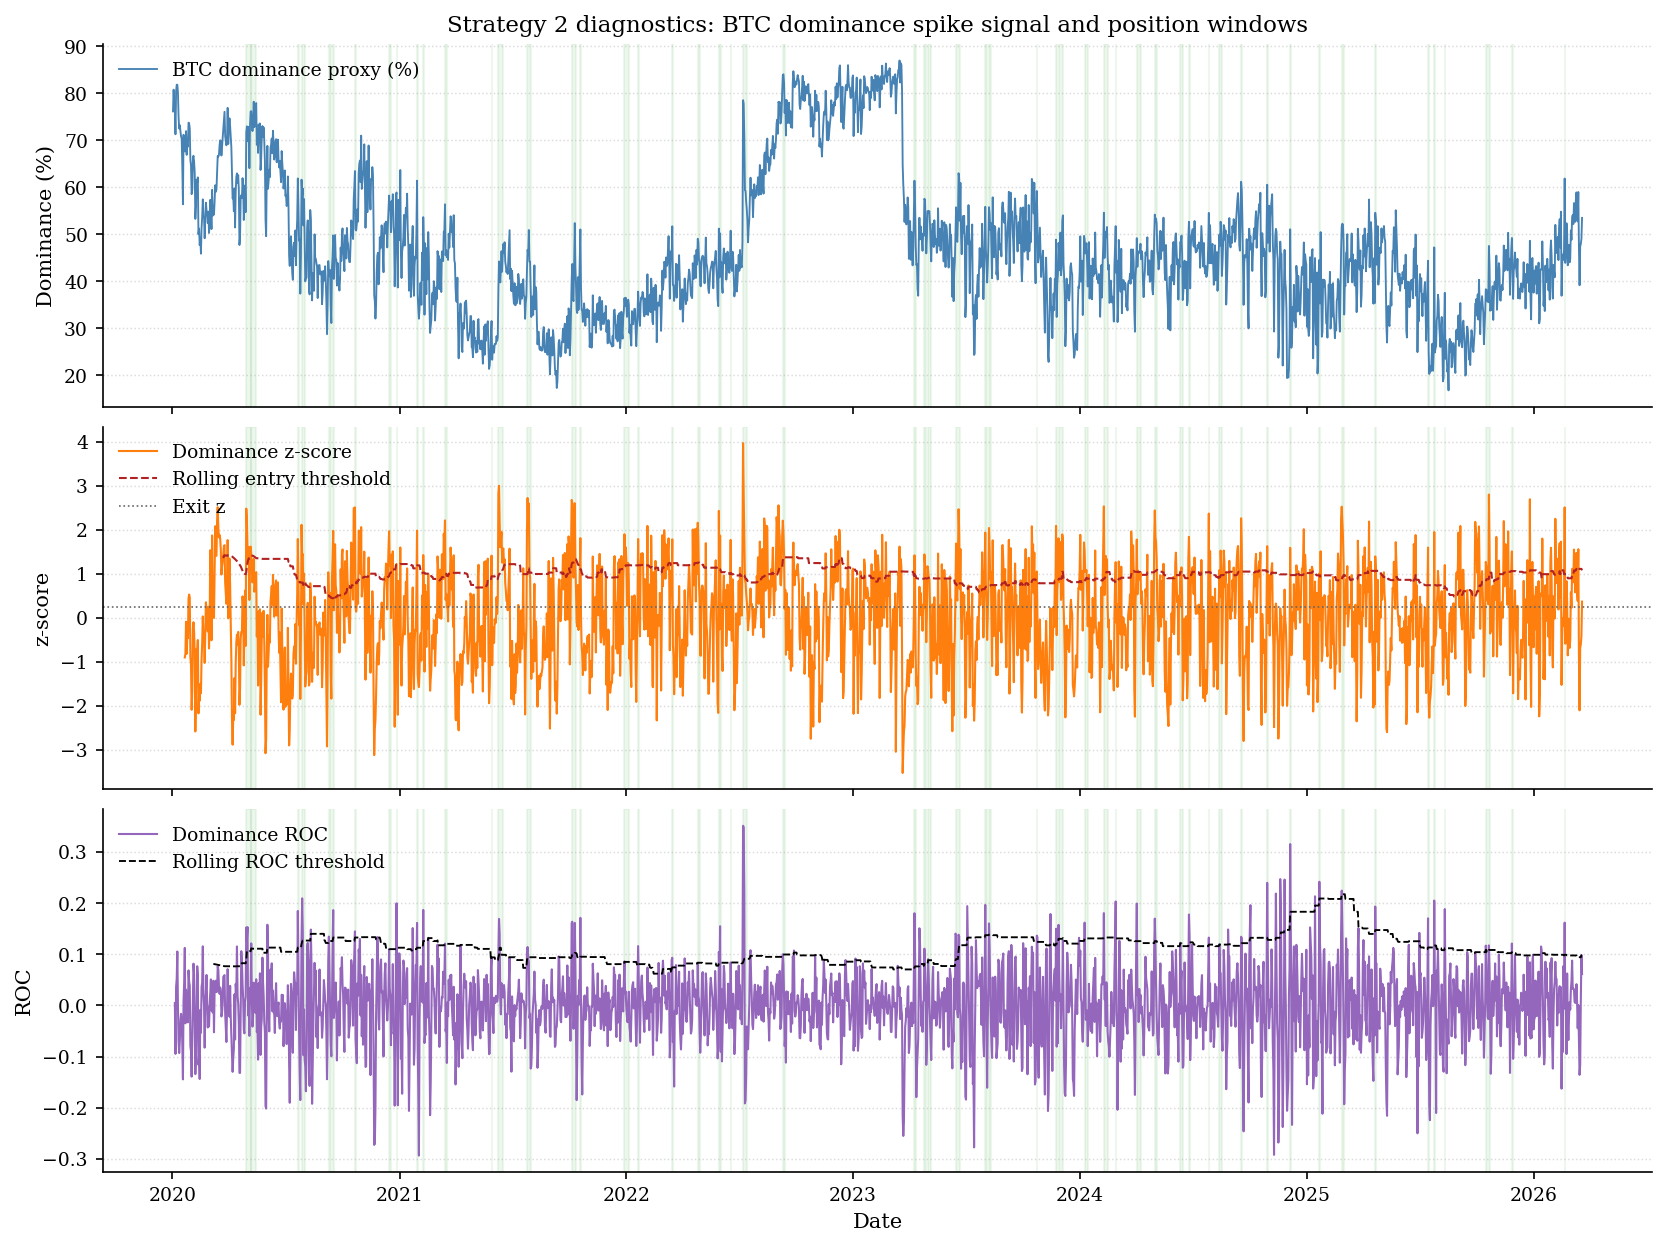

Strategy 2 baseline diagnostics
{
  "entry_pct": 0.8,
  "lookback": 126,
  "exit_z": 0.25,
  "max_hold": 7,
  "roc_window": 3,
  "roc_pct": 0.95,
  "crash_threshold": null,
  "gross_util": 1.0
}
Trade entries          : 56
Crash-filter blocks    : 0
In-market days         : 175
Average tradable alts  : 9.5
Mean notional turnover : 513.09
Mean weight turnover   : 0.0493
Mean half-spread (alts): 0.010266


In [20]:
S2_ALT_COINS = [c for c in cg_close.columns if c != 'BTC']
s2_features = build_s2_features(cg_close, cg_notional)
s2_baseline_params = make_s2_params(0.80, 126, 0.25, 7, 3, 0.95, None, gross_util=1.0)
s2_run = run_s2_strategy(
    s2_features,
    s2_baseline_params,
    S2_ALT_COINS,
    V0,
    s2_half_spread_frac,
    gross_util=s2_baseline_params.get('gross_util', 1.0),
)

btc_dom = s2_features['btc_dom']
dom_zscore = s2_features['dom_zscore']
position_mask = s2_run['position_mask'].fillna(0.0)


def _shade_active_periods(ax, index: pd.Index, active_mask: pd.Series, color: str = 'tab:green', alpha: float = 0.08):
    active = active_mask.fillna(0.0).astype(bool)
    start = None
    for dt, is_active in active.items():
        if is_active and start is None:
            start = dt
        elif not is_active and start is not None:
            ax.axvspan(start, dt, color=color, alpha=alpha)
            start = None
    if start is not None:
        ax.axvspan(start, index.max(), color=color, alpha=alpha)


fig, axes = plt.subplots(3, 1, figsize=(11, 8.2), sharex=True, constrained_layout=True)

btc_dom_pct = btc_dom * 100.0
axes[0].plot(btc_dom_pct.index, btc_dom_pct, color='steelblue', linewidth=0.9, label='BTC dominance proxy (%)')
_shade_active_periods(axes[0], btc_dom_pct.index, position_mask)
axes[0].set_ylabel('Dominance (%)')
axes[0].set_title('Strategy 2 diagnostics: BTC dominance spike signal and position windows')
axes[0].legend(loc='upper left', frameon=False)
axes[0].grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)

axes[1].plot(dom_zscore.index, dom_zscore, color='tab:orange', linewidth=1.0, label='Dominance z-score')
axes[1].plot(s2_run['rolling_entry_threshold'].index, s2_run['rolling_entry_threshold'], color='firebrick', linewidth=1.0, linestyle='--', label='Rolling entry threshold')
axes[1].axhline(s2_baseline_params['exit_z'], color='0.4', linestyle=':', linewidth=0.8, label='Exit z')
_shade_active_periods(axes[1], dom_zscore.index, position_mask)
axes[1].set_ylabel('z-score')
axes[1].legend(loc='upper left', frameon=False)
axes[1].grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)

axes[2].plot(s2_run['dom_roc'].index, s2_run['dom_roc'], color='tab:purple', linewidth=1.0, label='Dominance ROC')
axes[2].plot(s2_run['rolling_roc_threshold'].index, s2_run['rolling_roc_threshold'], color='black', linewidth=0.9, linestyle='--', label='Rolling ROC threshold')
_shade_active_periods(axes[2], s2_run['dom_roc'].index, position_mask)
axes[2].set_ylabel('ROC')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left', frameon=False)
axes[2].grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

maybe_save(fig, 'btc_dominance_rsi')
plt.show()

print('Strategy 2 baseline diagnostics')
print(json.dumps(s2_baseline_params, indent=2))
print(f"Trade entries          : {len(s2_run['trade_entries'])}")
print(f"Crash-filter blocks    : {len(s2_run['crash_blocks'])}")
print(f"In-market days         : {int(s2_run['weights'].sum(axis=1).gt(0).sum())}")
print(f"Average tradable alts  : {s2_run['available_alt_count'][s2_run['weights'].sum(axis=1).gt(0)].mean():.1f}")
print(f"Mean notional turnover : {s2_run['turnover'].mean():.2f}")
print(f"Mean weight turnover   : {s2_run['weight_turnover'].mean():.4f}")
print(f"Mean half-spread (alts): {s2_half_spread_frac[S2_ALT_COINS].stack().dropna().mean():.6f}")


## Strategy 2 Baseline Performance and Sensitivity Scan

Before tuning, the notebook evaluates the baseline model on the development sample, the full sample, and the final holdout. It then runs the original 4?4 `ENTRY_PCT ? ROC_PCT` sensitivity grid, now using the same `run_s2_strategy` implementation, the same one-bar execution lag, and the same Abdi?Ranaldo cost model as the baseline and the later Optuna section.


,n_days,trade_entries,active_days,total_return,ann_return,sharpe,sortino,calmar,max_drawdown,total_net_pnl,cost_drag,mean_turnover
sample,,,,,,,,,,,,
Baseline / dev,2144,54,172,0.499162,0.048742,0.390448,0.215410,0.143519,-0.339624,4991.621212,0.970756,524.566027
Baseline / full,2270,56,175,0.438062,0.041155,0.347564,0.189399,0.121178,-0.339624,4380.621904,0.992109,513.087798
Baseline / holdout,126,2,3,-0.040756,-0.079851,-2.898961,-1.342575,-1.959244,-0.040756,-610.999308,0.021352,317.775710


,trade_#,entry_date,exit_date,holding_bars,exit_reason,gross_return_fmt
0,1,2020-04-29,2020-05-06,7,max hold,-5.13%
1,2,2020-05-07,2020-05-14,7,max hold,0.01%
2,3,2020-07-21,2020-07-23,2,z-score exit,5.15%
3,4,2020-07-27,2020-08-01,5,z-score exit,14.90%
4,5,2020-09-09,2020-09-12,3,z-score exit,5.36%
5,6,2020-09-16,2020-09-17,1,z-score exit,3.74%
6,7,2020-10-21,2020-10-22,1,z-score exit,4.91%
7,8,2020-12-15,2020-12-18,3,z-score exit,8.52%
8,9,2020-12-27,2020-12-28,1,z-score exit,5.93%
9,10,2021-01-29,2021-01-30,1,z-score exit,6.66%


Baseline Strategy 2 win rate: 38/56 = 67.9%


,ENTRY_PCT,ROC_PCT,n_trades,pct_in_market,IS_sharpe,IS_max_dd
0,0.70,0.90,120,17.3%,0.23,-93.49%
1,0.75,0.85,133,19.7%,0.21,-96.35%
2,0.65,0.85,151,21.5%,0.15,-88.16%
3,0.70,0.85,148,21.0%,0.14,-88.16%
4,0.80,0.85,118,18.2%,0.12,-87.97%
5,0.80,0.90,96,14.9%,0.12,-79.05%
6,0.75,0.90,109,16.2%,0.08,-86.84%
7,0.80,0.80,133,20.0%,-0.15,-100.00%
8,0.65,0.90,121,17.5%,-0.17,-100.00%
9,0.65,0.80,172,23.9%,-0.35,-100.00%


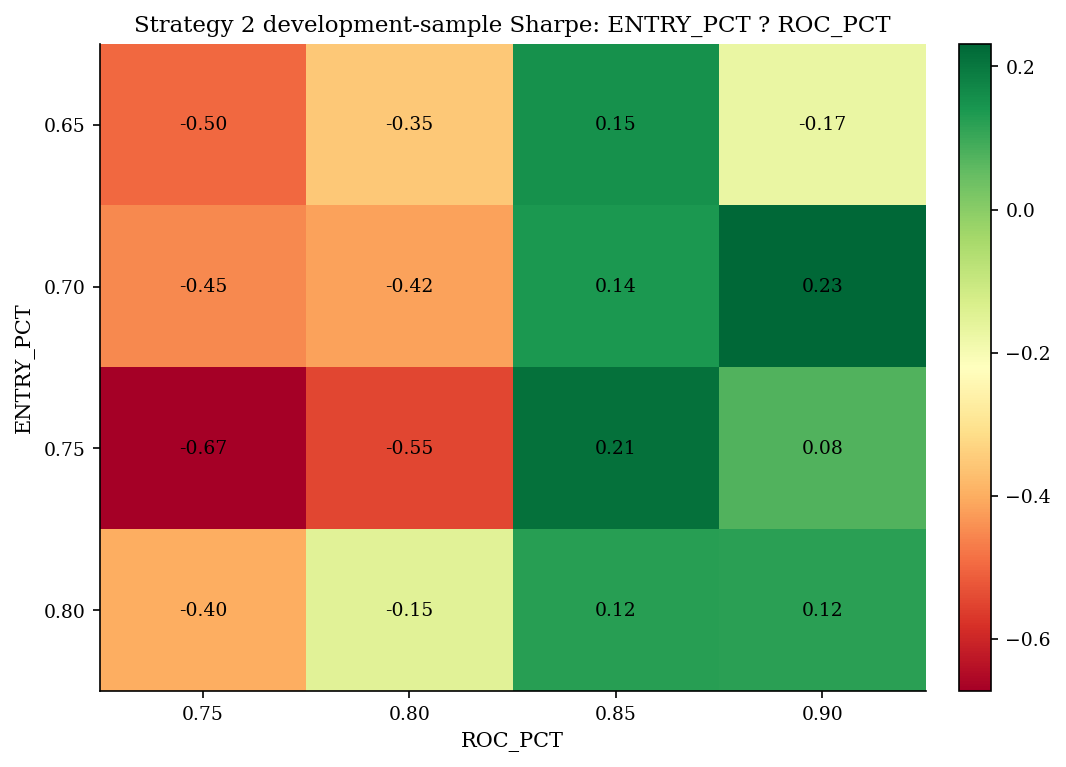

In [21]:
s2_baseline_dev = summarize_s2_run(s2_run, dev_index, 'Baseline / dev')
s2_baseline_full = summarize_s2_run(s2_run, s2_run['net_value'].index, 'Baseline / full')
s2_baseline_holdout = summarize_s2_run(s2_run, holdout_index, 'Baseline / holdout')
display(pd.DataFrame([s2_baseline_dev, s2_baseline_full, s2_baseline_holdout]).set_index('sample'))

trade_log_preview = s2_run['trade_log'].copy()
if len(trade_log_preview):
    trade_log_preview['gross_return_fmt'] = trade_log_preview['gross_return'].map(lambda x: f'{x:.2%}')
    display(trade_log_preview[['trade_#', 'entry_date', 'exit_date', 'holding_bars', 'exit_reason', 'gross_return_fmt']].head(12))
    wins = int((trade_log_preview['gross_return'] > 0).sum())
    print(f"Baseline Strategy 2 win rate: {wins}/{len(trade_log_preview)} = {wins / len(trade_log_preview):.1%}")

ENTRY_PCT_GRID = [0.65, 0.70, 0.75, 0.80]
ROC_PCT_GRID = [0.75, 0.80, 0.85, 0.90]

s2_sens_rows = []
for entry_pct in ENTRY_PCT_GRID:
    for roc_pct in ROC_PCT_GRID:
        params = dict(s2_baseline_params)
        params['entry_pct'] = float(entry_pct)
        params['roc_pct'] = float(roc_pct)
        run_variant = run_s2_strategy(
            s2_features,
            params,
            S2_ALT_COINS,
            V0,
            s2_half_spread_frac,
            gross_util=params.get('gross_util', 1.0),
        )
        summary = summarize_s2_run(run_variant, dev_index, f'entry={entry_pct:.2f}, roc={roc_pct:.2f}')
        s2_sens_rows.append({
            'ENTRY_PCT': entry_pct,
            'ROC_PCT': roc_pct,
            'n_trades': summary['trade_entries'],
            'pct_in_market': summary['active_days'] / max(1, len(dev_index)),
            'IS_sharpe': summary['sharpe'],
            'IS_max_dd': summary['max_drawdown'],
        })

s2_sens_df = pd.DataFrame(s2_sens_rows)
display(
    s2_sens_df.sort_values('IS_sharpe', ascending=False)
    .reset_index(drop=True)
    .assign(
        pct_in_market=lambda d: d['pct_in_market'].map('{:.1%}'.format),
        IS_sharpe=lambda d: d['IS_sharpe'].map(lambda x: f'{x:.2f}' if np.isfinite(x) else 'n/a'),
        IS_max_dd=lambda d: d['IS_max_dd'].map(lambda x: f'{x:.2%}' if np.isfinite(x) else 'n/a'),
    )
)

sharpe_grid = s2_sens_df.pivot(index='ENTRY_PCT', columns='ROC_PCT', values='IS_sharpe')
fig_sens, ax_sens = plt.subplots(figsize=(7, 5), constrained_layout=True)
im = ax_sens.imshow(sharpe_grid.to_numpy().astype(float), aspect='auto', cmap='RdYlGn')
ax_sens.set_title('Strategy 2 development-sample Sharpe: ENTRY_PCT ? ROC_PCT')
ax_sens.set_xlabel('ROC_PCT')
ax_sens.set_ylabel('ENTRY_PCT')
ax_sens.set_xticks(range(len(sharpe_grid.columns)), [f'{v:.2f}' for v in sharpe_grid.columns])
ax_sens.set_yticks(range(len(sharpe_grid.index)), [f'{v:.2f}' for v in sharpe_grid.index])
for r in range(sharpe_grid.shape[0]):
    for c in range(sharpe_grid.shape[1]):
        value = sharpe_grid.iloc[r, c]
        ax_sens.text(c, r, f'{value:.2f}' if np.isfinite(value) else 'n/a', ha='center', va='center', fontsize=9)
fig_sens.colorbar(im, ax=ax_sens, fraction=0.046, pad=0.04)
maybe_save(fig_sens, 's2_new_signal_sensitivity')
plt.show()


## Strategy 2 Optuna Tuning on the Corrected Strategy Contract

The tuning section below searches the same dominance-level-z-score plus ROC family used by the baseline and sensitivity scan. The search space is now narrowed around the combinations that materially improved trade quality, and the objective penalises ultra-sparse solutions so the tuned model does not win by barely trading.


Existing Strategy 2 trials: 0
Additional trials to run : 80


c:\Users\peter\Documents\GitHub\Algo-Trading-Project\strategy2_pipeline.py:343: RuntimeWarning: invalid value encountered in scalar divide
  "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1.0),
c:\Users\peter\Documents\GitHub\Algo-Trading-Project\strategy2_pipeline.py:343: RuntimeWarning: invalid value encountered in scalar divide
  "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1.0),
c:\Users\peter\Documents\GitHub\Algo-Trading-Project\strategy2_pipeline.py:343: RuntimeWarning: invalid value encountered in scalar divide
  "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1.0),
c:\Users\peter\Documents\GitHub\Algo-Trading-Project\strategy2_pipeline.py:343: RuntimeWarning: invalid value encountered in scalar divide
  "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1.0),
c:\Users\peter\Documents\GitHub\Algo-Trading-Project\strategy2_pipeline.py:343: RuntimeWarning: invalid value encountered in scalar divide
  "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1.0),
c:\Users\peter\Docum

{
  "study_name": "strategy2_levelz_eq_abdi_ranaldo_v2",
  "n_trials": 80,
  "objective_value": -0.0440563190130733,
  "params": {
    "entry_pct": 0.8,
    "lookback": 126,
    "exit_z": 0.0,
    "max_hold": 7,
    "roc_window": 3,
    "roc_pct": 0.95,
    "crash_threshold": null,
    "gross_util": 2.0
  },
  "derived_params": {
    "entry_pct": 0.8,
    "lookback": 126,
    "exit_z": 0.0,
    "max_hold": 7,
    "roc_window": 3,
    "roc_pct": 0.95,
    "crash_threshold": null,
    "gross_util": 2.0
  },
  "user_attrs": {
    "active_fold_count": 14,
    "activity_penalty": 0.0,
    "entry_pct": 0.8,
    "exit_z": 0.0,
    "gross_util": 2.0,
    "inactivity_penalty": 0.0,
    "invalid_reason": "",
    "lookback": 126,
    "max_hold": 7,
    "mean_active_days_per_fold": 8.2,
    "mean_val_max_dd": -0.1151818015395078,
    "mean_val_return": 0.009879683155291514,
    "mean_val_sharpe": 0.18226362982953845,
    "objective_score": -0.0440563190130733,
    "penalty_reasons": "",
    "roc_p

,number,objective_score,entry_pct,lookback,exit_z,max_hold,roc_window,roc_pct,crash_threshold,gross_util,mean_val_sharpe,std_val_sharpe,total_dev_trades,traded_fold_share,activity_penalty,invalid_reason
66,66,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
67,67,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
70,70,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
71,71,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
72,72,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
73,73,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
74,74,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
75,75,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
79,79,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,
60,60,-0.044056,0.8,126,0.0,7,3,0.95,off,2.0,0.182264,1.5088,54.0,0.933333,0.0,


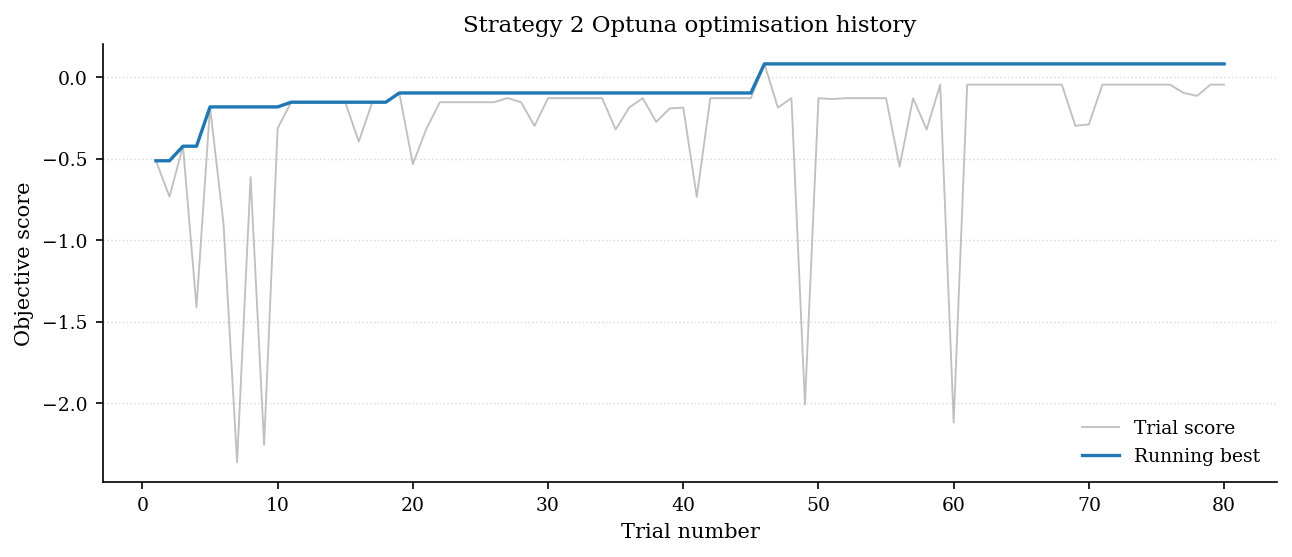

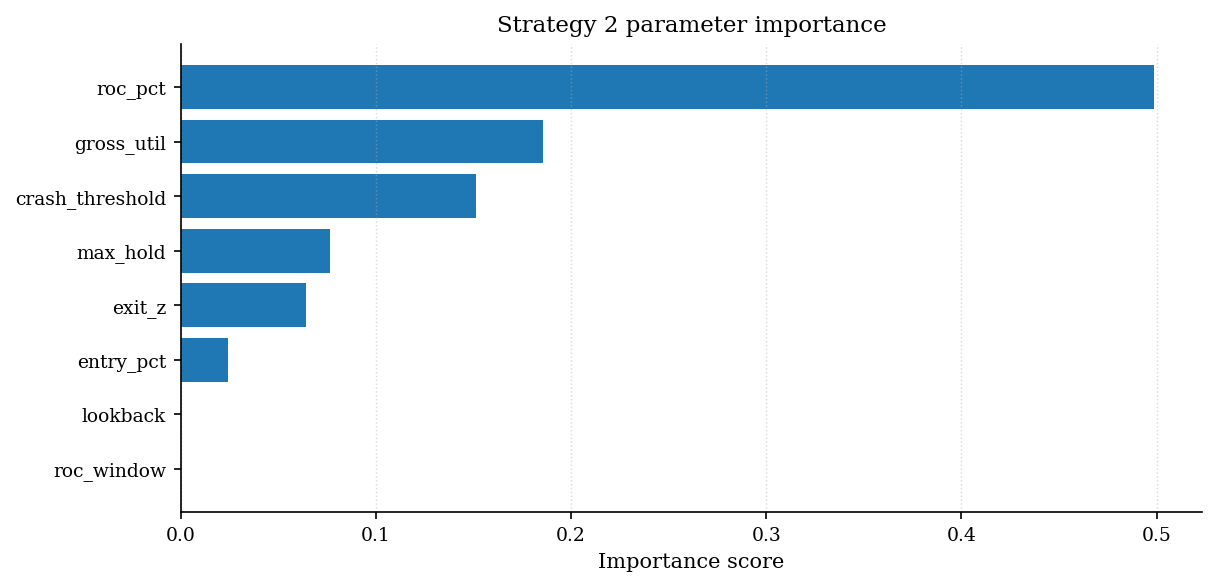

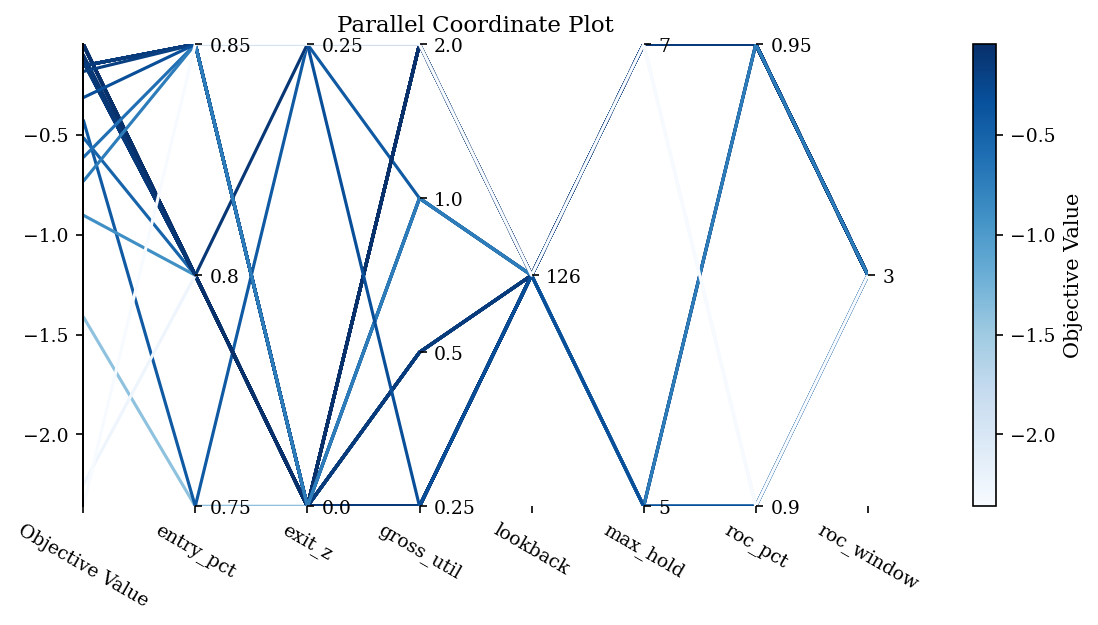

In [22]:
S2_OPTUNA_TARGET_TRIALS = 80
S2_OPTUNA_STUDY_NAME = 'strategy2_levelz_eq_abdi_ranaldo_v2'
S2_OPTUNA_DB_PATH = OUT_DIR / 's2_optuna_levelz_eq_abdi_ranaldo_v2.db'
S2_OPTUNA_STORAGE = f'sqlite:///{S2_OPTUNA_DB_PATH}'


def format_crash_threshold(value):
    return 'off' if value is None or (isinstance(value, float) and np.isnan(value)) else f'{value:.0%}'


def optuna_objective(trial: optuna.Trial) -> float:
    params = make_s2_params(
        entry_pct=trial.suggest_categorical('entry_pct', [0.75, 0.80, 0.85]),
        lookback=trial.suggest_categorical('lookback', [126]),
        exit_z=trial.suggest_categorical('exit_z', [0.0, 0.25]),
        max_hold=trial.suggest_categorical('max_hold', [5, 7]),
        roc_window=trial.suggest_categorical('roc_window', [3]),
        roc_pct=trial.suggest_categorical('roc_pct', [0.90, 0.95]),
        crash_threshold=trial.suggest_categorical('crash_threshold', [None, -0.15]),
        gross_util=trial.suggest_categorical('gross_util', [0.25, 0.50, 1.00, 2.00]),
    )
    run_state = run_s2_strategy(
        s2_features,
        params,
        S2_ALT_COINS,
        V0,
        s2_half_spread_frac,
        gross_util=params.get('gross_util', 1.0),
    )
    trial_score = score_s2_trial(run_state, wf_folds, dev_index)
    activity_penalty = 0.0
    if trial_score['total_dev_trades'] < 40:
        activity_penalty += 0.50
    if np.isfinite(trial_score['mean_active_days_per_fold']) and trial_score['mean_active_days_per_fold'] < 2.0:
        activity_penalty += 0.25
    objective_value = float(trial_score['score'] - activity_penalty)
    running = []
    for step, value in enumerate(trial_score['fold_df']['sharpe'], start=1):
        if np.isfinite(value):
            running.append(float(value))
        trial.report(float(np.mean(running)) if running else -1.0, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    for key, value in params.items():
        if key != 'crash_threshold':
            trial.set_user_attr(key, value)
    trial.set_user_attr('objective_score', objective_value)
    trial.set_user_attr('mean_val_sharpe', None if not np.isfinite(trial_score['mean_val_sharpe']) else float(trial_score['mean_val_sharpe']))
    trial.set_user_attr('std_val_sharpe', float(trial_score['std_val_sharpe']))
    trial.set_user_attr('mean_val_return', None if not np.isfinite(trial_score['mean_val_return']) else float(trial_score['mean_val_return']))
    trial.set_user_attr('mean_val_max_dd', None if not np.isfinite(trial_score['mean_val_max_dd']) else float(trial_score['mean_val_max_dd']))
    trial.set_user_attr('total_dev_trades', int(trial_score['total_dev_trades']))
    trial.set_user_attr('traded_fold_share', float(trial_score['traded_fold_share']))
    trial.set_user_attr('active_fold_count', int(trial_score['active_fold_count']))
    trial.set_user_attr('mean_active_days_per_fold', None if not np.isfinite(trial_score['mean_active_days_per_fold']) else float(trial_score['mean_active_days_per_fold']))
    trial.set_user_attr('inactivity_penalty', float(trial_score['inactivity_penalty']))
    trial.set_user_attr('activity_penalty', activity_penalty)
    trial.set_user_attr('penalty_reasons', trial_score['penalty_reasons'])
    trial.set_user_attr('invalid_reason', trial_score['invalid_reason'])
    return objective_value


if REFRESH_S2_TUNING and S2_OPTUNA_DB_PATH.exists():
    S2_OPTUNA_DB_PATH.unlink()

s2_study = optuna.create_study(
    study_name=S2_OPTUNA_STUDY_NAME,
    storage=S2_OPTUNA_STORAGE,
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=12, n_warmup_steps=4),
    load_if_exists=True,
)
existing_trials = len(s2_study.trials)
remaining_trials = max(0, S2_OPTUNA_TARGET_TRIALS - existing_trials)
print(f'Existing Strategy 2 trials: {existing_trials}')
print(f'Additional trials to run : {remaining_trials}')
if remaining_trials > 0:
    s2_study.optimize(optuna_objective, n_trials=remaining_trials, gc_after_trial=True, show_progress_bar=False)
else:
    print('Study already meets the target size; reusing persisted results.')

best_trial = s2_study.best_trial
s2_best_params = make_s2_params(
    best_trial.params['entry_pct'],
    best_trial.params['lookback'],
    best_trial.params['exit_z'],
    best_trial.params['max_hold'],
    best_trial.params['roc_window'],
    best_trial.params['roc_pct'],
    best_trial.params['crash_threshold'],
    gross_util=best_trial.params.get('gross_util', 1.0),
)
best_payload = {
    'study_name': S2_OPTUNA_STUDY_NAME,
    'n_trials': len(s2_study.trials),
    'objective_value': float(best_trial.value),
    'params': best_trial.params,
    'derived_params': s2_best_params,
    'user_attrs': best_trial.user_attrs,
}
(OUT_DIR / 's2_optuna_best_params.json').write_text(json.dumps(best_payload, indent=2, default=str), encoding='utf-8')
print(json.dumps(best_payload, indent=2, default=str))

s2_trials_df = s2_study.trials_dataframe(attrs=('number', 'value', 'params', 'state', 'user_attrs'))
rename_map = {
    'value': 'objective_score',
    'params_entry_pct': 'entry_pct',
    'params_lookback': 'lookback',
    'params_exit_z': 'exit_z',
    'params_max_hold': 'max_hold',
    'params_roc_window': 'roc_window',
    'params_roc_pct': 'roc_pct',
    'params_crash_threshold': 'crash_threshold',
    'params_gross_util': 'gross_util',
    'user_attrs_mean_val_sharpe': 'mean_val_sharpe',
    'user_attrs_std_val_sharpe': 'std_val_sharpe',
    'user_attrs_mean_val_return': 'mean_val_return',
    'user_attrs_mean_val_max_dd': 'mean_val_max_dd',
    'user_attrs_total_dev_trades': 'total_dev_trades',
    'user_attrs_traded_fold_share': 'traded_fold_share',
    'user_attrs_active_fold_count': 'active_fold_count',
    'user_attrs_mean_active_days_per_fold': 'mean_active_days_per_fold',
    'user_attrs_inactivity_penalty': 'inactivity_penalty',
    'user_attrs_activity_penalty': 'activity_penalty',
    'user_attrs_penalty_reasons': 'penalty_reasons',
    'user_attrs_invalid_reason': 'invalid_reason',
}
s2_trials_df = s2_trials_df.rename(columns={k: v for k, v in rename_map.items() if k in s2_trials_df.columns})
s2_trials_df['crash_threshold'] = s2_trials_df['crash_threshold'].map(format_crash_threshold)
s2_trials_df.to_csv(OUT_DIR / 's2_optuna_trials.csv', index=False)
completed_trials = s2_trials_df[s2_trials_df['state'] == 'COMPLETE'].copy().sort_values('objective_score', ascending=False)
display(completed_trials[['number', 'objective_score', 'entry_pct', 'lookback', 'exit_z', 'max_hold', 'roc_window', 'roc_pct', 'crash_threshold', 'gross_util', 'mean_val_sharpe', 'std_val_sharpe', 'total_dev_trades', 'traded_fold_share', 'activity_penalty', 'invalid_reason']].head(10))

fig_hist, ax_hist = plt.subplots(figsize=(8.5, 3.6), constrained_layout=True)
all_trials = np.arange(1, len(s2_trials_df) + 1)
all_scores = s2_trials_df['objective_score'].astype(float)
running_best = all_scores.cummax()
ax_hist.plot(all_trials, all_scores, color='0.65', linewidth=0.9, alpha=0.7, label='Trial score')
ax_hist.plot(all_trials, running_best, color='tab:blue', linewidth=1.6, label='Running best')
ax_hist.set_title('Strategy 2 Optuna optimisation history')
ax_hist.set_xlabel('Trial number')
ax_hist.set_ylabel('Objective score')
ax_hist.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_hist.legend(frameon=False)
maybe_save(fig_hist, 's2_optuna_optimization_history')
plt.show()

try:
    from optuna.importance import get_param_importances
except Exception:
    get_param_importances = None

importance = None
if get_param_importances is not None:
    try:
        importance = get_param_importances(s2_study)
    except Exception:
        importance = None

if importance:
    importance_df = pd.DataFrame({'parameter': list(importance.keys()), 'importance': list(importance.values())}).sort_values('importance', ascending=True)
else:
    fallback_rows = []
    fallback_source = completed_trials.dropna(subset=['objective_score'])
    overall_mean = fallback_source['objective_score'].mean()
    for param in ['entry_pct', 'lookback', 'exit_z', 'max_hold', 'roc_window', 'roc_pct', 'crash_threshold', 'gross_util']:
        if param not in fallback_source.columns:
            continue
        series = fallback_source[param]
        if pd.api.types.is_numeric_dtype(series):
            aligned = pd.concat([series, fallback_source['objective_score']], axis=1).dropna()
            score = abs(aligned.corr(method='spearman').iloc[0, 1]) if len(aligned) >= 2 else np.nan
        else:
            group_means = fallback_source.groupby(param, dropna=False)['objective_score'].mean()
            group_weights = fallback_source.groupby(param, dropna=False).size()
            score = (((group_means - overall_mean) ** 2) * group_weights).sum() / max(len(fallback_source), 1)
        fallback_rows.append({'parameter': param, 'importance': 0.0 if pd.isna(score) else float(score)})
    importance_df = pd.DataFrame(fallback_rows).sort_values('importance', ascending=True)

fig_imp, ax_imp = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
ax_imp.barh(importance_df['parameter'], importance_df['importance'], color='tab:blue')
ax_imp.set_title('Strategy 2 parameter importance')
ax_imp.set_xlabel('Importance score')
ax_imp.grid(True, axis='x', linestyle=':', linewidth=0.7, alpha=0.45)
maybe_save(fig_imp, 's2_optuna_param_importance')
plt.show()

try:
    from optuna.visualization.matplotlib import plot_parallel_coordinate
except Exception:
    plot_parallel_coordinate = None

if plot_parallel_coordinate is not None:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            ax_pc = plot_parallel_coordinate(s2_study, params=['entry_pct', 'lookback', 'exit_z', 'max_hold', 'roc_window', 'roc_pct', 'gross_util'])
        fig_pc = ax_pc.figure
        fig_pc.set_size_inches(9, 4)
        maybe_save(fig_pc, 's2_optuna_parallel_coordinate')
        plt.show()
    except Exception:
        pass


## Strategy 2 Tuned vs Baseline and Final Cross-Strategy Holdout Comparison

The tuned Strategy 2 model now comes from the corrected Optuna study and is compared against the baseline using the same run function, the same one-bar execution lag, the same Abdi?Ranaldo cost model, and the same development / holdout splits.


,trade_entries,active_days,total_return,ann_return,sharpe,max_drawdown,cost_drag,mean_turnover
sample,,,,,,,,
Baseline / dev,54,172,0.499162,0.048742,0.390448,-0.339624,0.970756,524.566027
Tuned / dev,54,193,0.681751,0.063005,0.343252,-0.598882,2.096392,1054.276355


,trade_entries,active_days,total_return,ann_return,sharpe,max_drawdown,cost_drag,mean_turnover
sample,,,,,,,,
Baseline / full,56,175,0.438062,0.041155,0.347564,-0.339624,0.992109,513.087798
Tuned / full,56,196,0.559551,0.050571,0.308277,-0.598882,2.135176,1031.034355


,trade_entries,active_days,total_return,ann_return,sharpe,max_drawdown,cost_drag,mean_turnover
sample,,,,,,,,
Baseline / holdout,2,3,-0.040756,-0.079851,-2.898961,-0.040756,0.021352,317.77571
Tuned / holdout,2,3,-0.072662,-0.140045,-2.912304,-0.072662,0.038785,635.55142


,n_days,trade_entries,active_days,total_return,ann_return,sharpe,sortino,calmar,max_drawdown,total_net_pnl,cost_drag,mean_turnover,gross_util_selected
sample,,,,,,,,,,,,,
Strategy 2 baseline,126.0,2.0,3.0,-0.040756,-0.079851,-2.898961,-1.342575,-1.959244,-0.040756,-610.999308,0.021352,317.77571,1.0
Strategy 2 tuned,126.0,2.0,3.0,-0.072662,-0.140045,-2.912304,-1.376743,-1.927338,-0.072662,-1221.998616,0.038785,635.55142,2.0
Strategy 1 selected WF,NaN,NaN,NaN,0.060402,0.125507,1.300222,NaN,NaN,-0.037758,NaN,NaN,NaN,0.1
BTC buy-and-hold,NaN,NaN,NaN,-0.262411,-0.458606,-1.160819,NaN,NaN,-0.351122,NaN,NaN,NaN,NaN


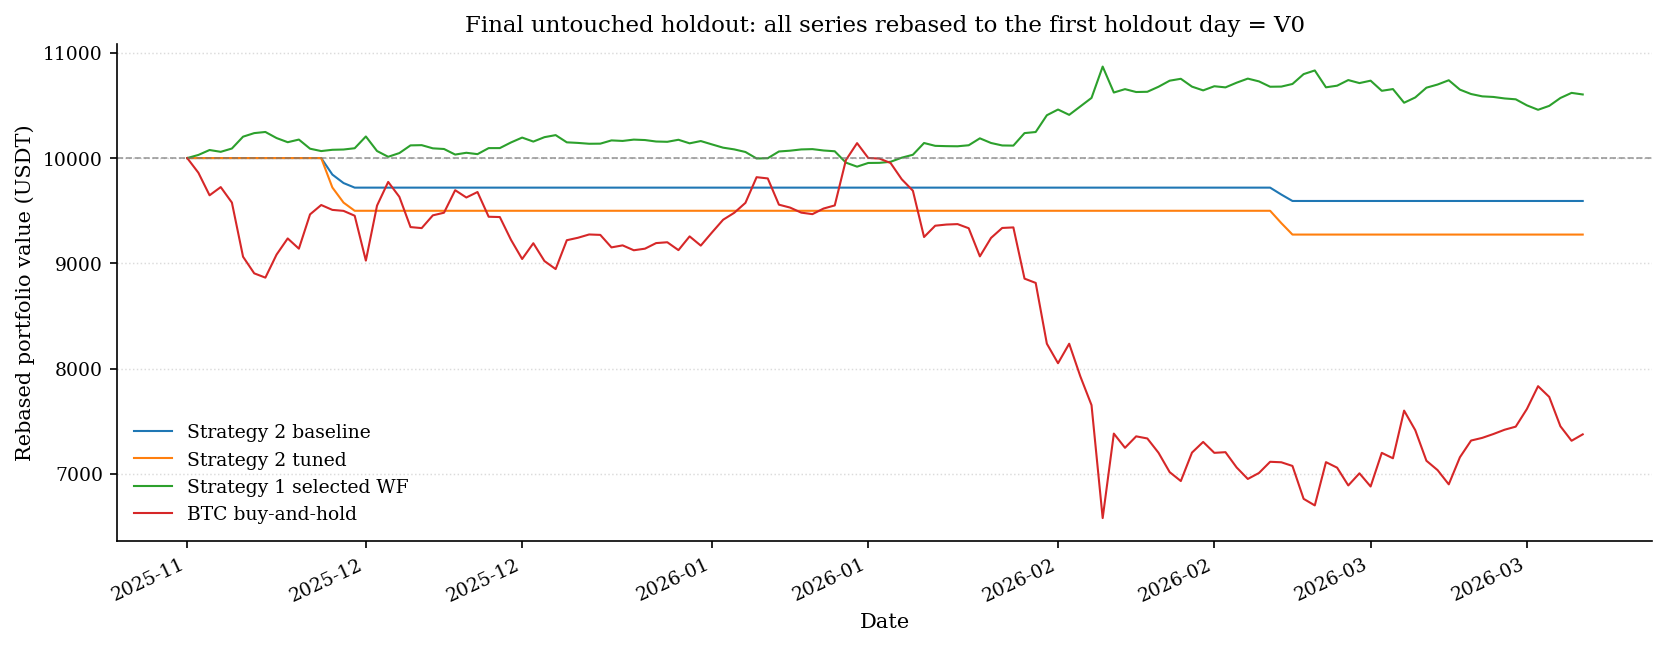

In [23]:
s2_tuned_run = run_s2_strategy(
    s2_features,
    s2_best_params,
    S2_ALT_COINS,
    V0,
    s2_half_spread_frac,
    gross_util=s2_best_params.get('gross_util', 1.0),
)

s2_tuned_dev = summarize_s2_run(s2_tuned_run, dev_index, 'Tuned / dev')
s2_tuned_full = summarize_s2_run(s2_tuned_run, s2_tuned_run['net_value'].index, 'Tuned / full')
s2_tuned_holdout = summarize_s2_run(s2_tuned_run, holdout_index, 'Tuned / holdout')

comparison_cols = ['sample', 'trade_entries', 'active_days', 'total_return', 'ann_return', 'sharpe', 'max_drawdown', 'cost_drag', 'mean_turnover']
display(pd.DataFrame([s2_baseline_dev, s2_tuned_dev])[comparison_cols].set_index('sample'))
display(pd.DataFrame([s2_baseline_full, s2_tuned_full])[comparison_cols].set_index('sample'))
display(pd.DataFrame([s2_baseline_holdout, s2_tuned_holdout])[comparison_cols].set_index('sample'))

btc_bh = (V0 * (1.0 + cg_close['BTC'].pct_change().fillna(0.0)).cumprod()).rename('BTC buy-and-hold')

def summarize_equity_series(equity: pd.Series, mask: pd.Index, label: str) -> dict:
    eq = equity.reindex(mask).dropna()
    r = eq.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    if len(eq) < 2:
        return {'sample': label, 'total_return': np.nan, 'ann_return': np.nan, 'sharpe': np.nan, 'max_drawdown': np.nan}
    ann_return = float((eq.iloc[-1] / eq.iloc[0]) ** (TRADING_DAYS / len(r)) - 1.0) if len(r) > 1 and eq.iloc[0] > 0 and eq.iloc[-1] > 0 else np.nan
    return {
        'sample': label,
        'total_return': float(eq.iloc[-1] / eq.iloc[0] - 1.0),
        'ann_return': ann_return,
        'sharpe': sharpe_ratio(r),
        'max_drawdown': max_drawdown(eq),
    }

holdout_rows = [
    {
        **s2_baseline_holdout,
        'sample': 'Strategy 2 baseline',
        'gross_util_selected': float(s2_baseline_params.get('gross_util', 1.0)),
    },
    {
        **s2_tuned_holdout,
        'sample': 'Strategy 2 tuned',
        'gross_util_selected': float(s2_best_params.get('gross_util', 1.0)),
    },
    {
        **summarize_equity_series(eq_oos, holdout_index, 'Strategy 1 selected WF'),
        'gross_util_selected': float(strategy1_selected_params.get('gross_util', np.nan)),
    },
    {
        **summarize_equity_series(btc_bh, holdout_index, 'BTC buy-and-hold'),
        'gross_util_selected': np.nan,
    },
]
display(pd.DataFrame(holdout_rows).set_index('sample'))


### Gross vs Net OOS Performance Decomposition

In [ ]:
def _safe_cost_to_gross_ratio(total_cost: float, total_gross_pnl: float) -> float:
    if not np.isfinite(total_cost) or not np.isfinite(total_gross_pnl) or total_gross_pnl == 0:
        return np.nan
    return 100.0 * total_cost / abs(total_gross_pnl)


def _strategy1_holdout_breakdown(label: str, model: dict, window: pd.Index) -> dict:
    gross_pnl = model['out']['gross_pnl'].reindex(window)
    gross_base = model['out']['net_portfolio_value'].shift(1).reindex(window)
    gross_returns = gross_pnl.div(gross_base.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
    gross_sharpe = sharpe_ratio(gross_returns, TRADING_DAYS)
    net_sharpe = model['summary']['sharpe']
    return {
        'sample': label,
        'total_gross_pnl': model['summary']['total_gross_pnl'],
        'total_cost': model['summary']['total_cost'],
        'total_net_pnl': model['summary']['total_net_pnl'],
        'cost_to_gross_ratio': _safe_cost_to_gross_ratio(
            model['summary']['total_cost'],
            model['summary']['total_gross_pnl'],
        ),
        'gross_sharpe': gross_sharpe,
        'net_sharpe': net_sharpe,
        'sharpe_drag': gross_sharpe - net_sharpe if np.isfinite(gross_sharpe) and np.isfinite(net_sharpe) else np.nan,
    }


def _strategy2_holdout_breakdown(label: str, run: dict, summary: dict, window: pd.Index) -> dict:
    gross_pnl = run['gross_pnl_daily'].reindex(window).dropna()
    cost_pnl = run['cost_pnl_daily'].reindex(window).dropna()
    gross_base = run['net_value'].shift(1).reindex(window)
    gross_returns = gross_pnl.div(gross_base.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
    total_gross_pnl = float(gross_pnl.sum()) if len(gross_pnl) else np.nan
    total_cost = float(cost_pnl.sum()) if len(cost_pnl) else np.nan
    total_net_pnl = total_gross_pnl - total_cost if np.isfinite(total_gross_pnl) and np.isfinite(total_cost) else np.nan
    gross_sharpe = sharpe_ratio(gross_returns, TRADING_DAYS)
    net_sharpe = summary['sharpe']
    return {
        'sample': label,
        'total_gross_pnl': total_gross_pnl,
        'total_cost': total_cost,
        'total_net_pnl': total_net_pnl,
        'cost_to_gross_ratio': _safe_cost_to_gross_ratio(total_cost, total_gross_pnl),
        'gross_sharpe': gross_sharpe,
        'net_sharpe': net_sharpe,
        'sharpe_drag': gross_sharpe - net_sharpe if np.isfinite(gross_sharpe) and np.isfinite(net_sharpe) else np.nan,
    }


gross_vs_net_oos = pd.DataFrame([
    _strategy1_holdout_breakdown('Strategy 1 baseline', baseline_model, holdout_index),
    _strategy1_holdout_breakdown('Strategy 1 walk-forward selected', selected_model, holdout_index),
    _strategy2_holdout_breakdown('Strategy 2 baseline', s2_run, s2_baseline_holdout, holdout_index),
    _strategy2_holdout_breakdown('Strategy 2 tuned', s2_tuned_run, s2_tuned_holdout, holdout_index),
]).set_index('sample')

display(gross_vs_net_oos.round(3))


In [ ]:
def rebase_to_v0(series: pd.Series) -> pd.Series | None:
    s = series.reindex(holdout_index).dropna()
    if len(s) < 2 or s.iloc[0] <= 0:
        return None
    return s / s.iloc[0] * V0

plot_series = {
    'Strategy 2 baseline': rebase_to_v0(s2_run['net_value']),
    'Strategy 2 tuned': rebase_to_v0(s2_tuned_run['net_value']),
    'Strategy 1 selected WF': rebase_to_v0(eq_oos),
    'BTC buy-and-hold': rebase_to_v0(btc_bh),
}
plot_series = {k: v for k, v in plot_series.items() if v is not None}
if len(plot_series) >= 2:
    fig_holdout, ax_holdout = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
    for label, series in plot_series.items():
        ax_holdout.plot(series.index, series, linewidth=1.0, label=label)
    ax_holdout.axhline(V0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
    ax_holdout.set_title('Final untouched holdout: all series rebased to the first holdout day = V0')
    ax_holdout.set_ylabel('Rebased portfolio value (USDT)')
    ax_holdout.set_xlabel('Date')
    ax_holdout.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
    ax_holdout.grid(False, axis='x')
    ax_holdout.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax_holdout.xaxis.get_majorticklabels(), rotation=25, ha='right')
    ax_holdout.legend(loc='best', frameon=False)
    maybe_save(fig_holdout, 's2_optuna_holdout_comparison')
    plt.show()

if s2_tuned_holdout['trade_entries'] == 0:
    print('Tuned Strategy 2 executed no holdout trades. Treat the holdout as a quiet-regime outcome rather than a notebook failure.')


## Strategy 2 In-Sample Performance Analysis

The tuned Strategy 2 model improved the signal specification, but its economic usefulness depends on how that tuning changed the **development-sample** path, selectivity, drawdown profile, and benchmark-relative performance. This section compares the tuned strategy against the original baseline and BTC buy-and-hold.


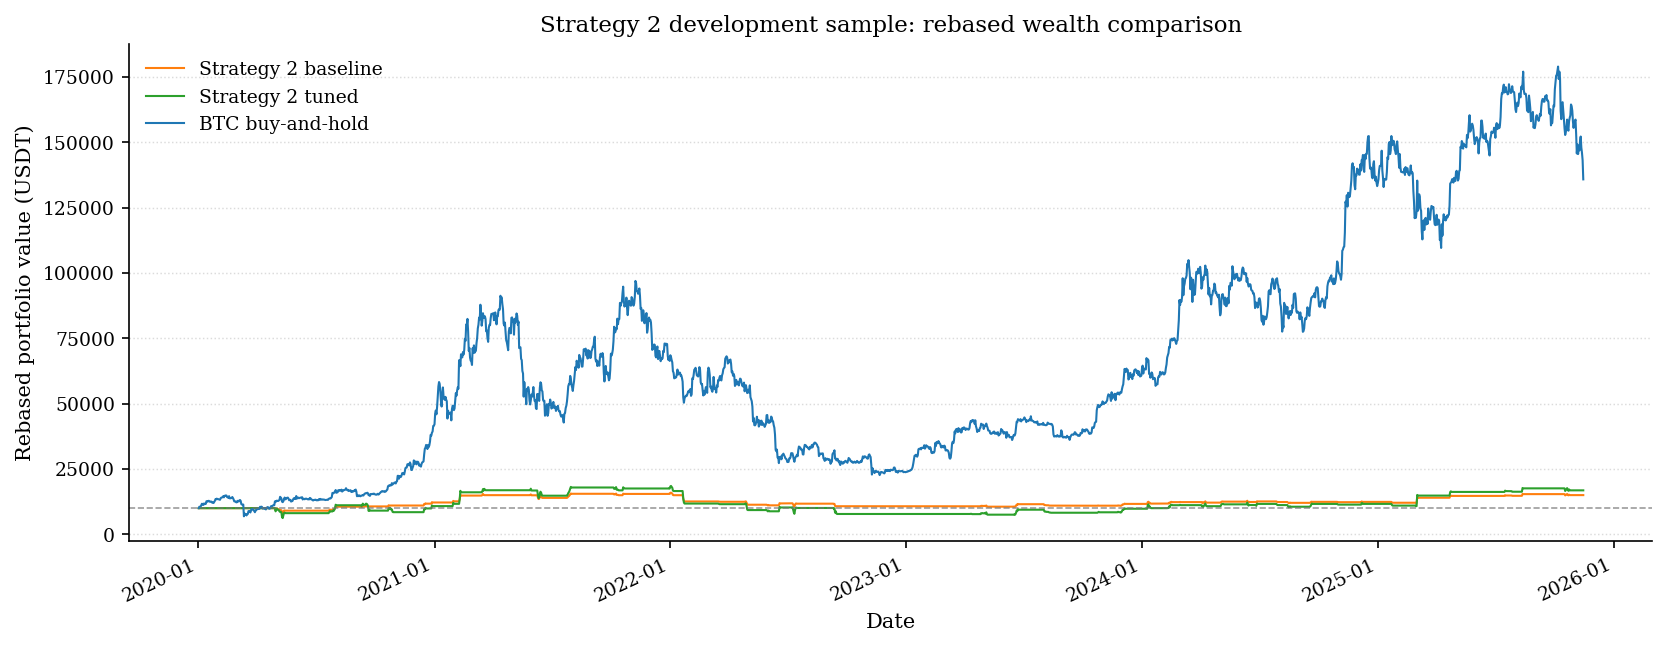

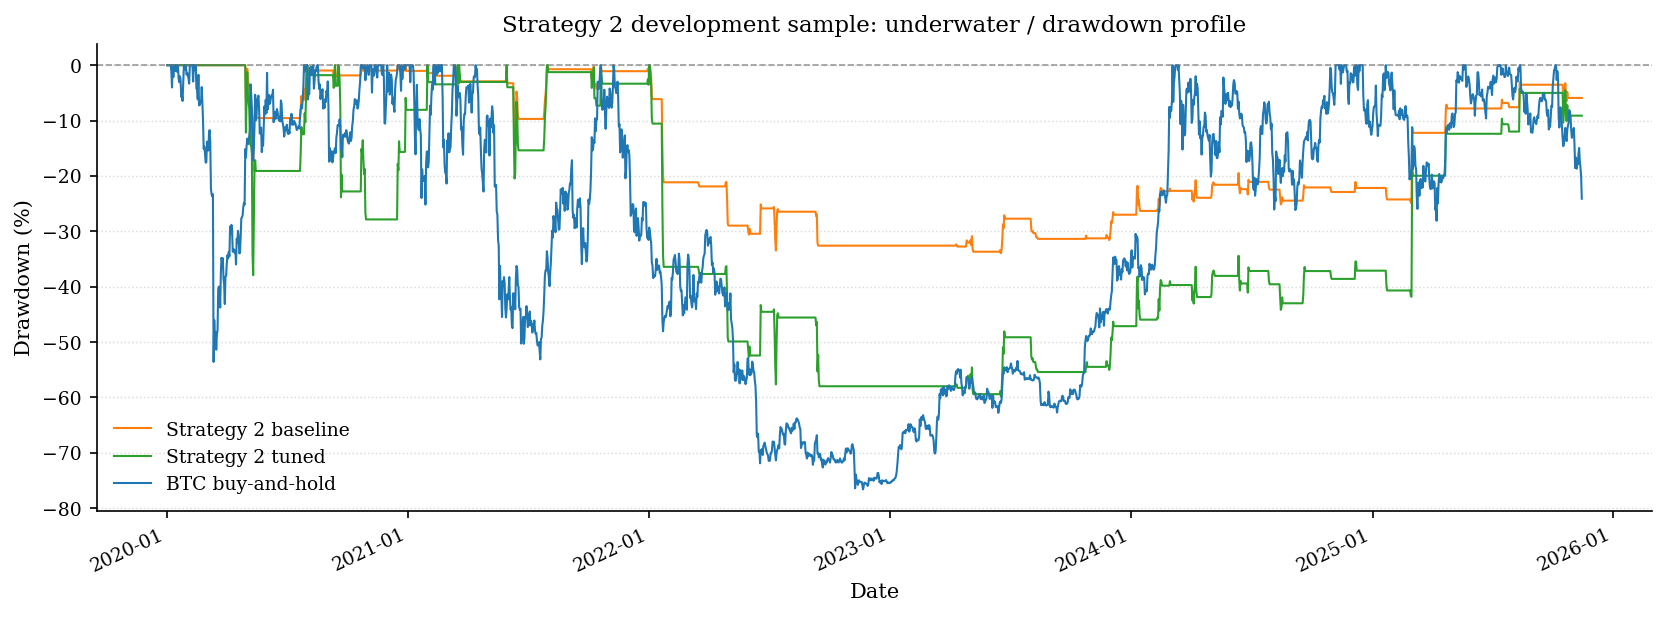

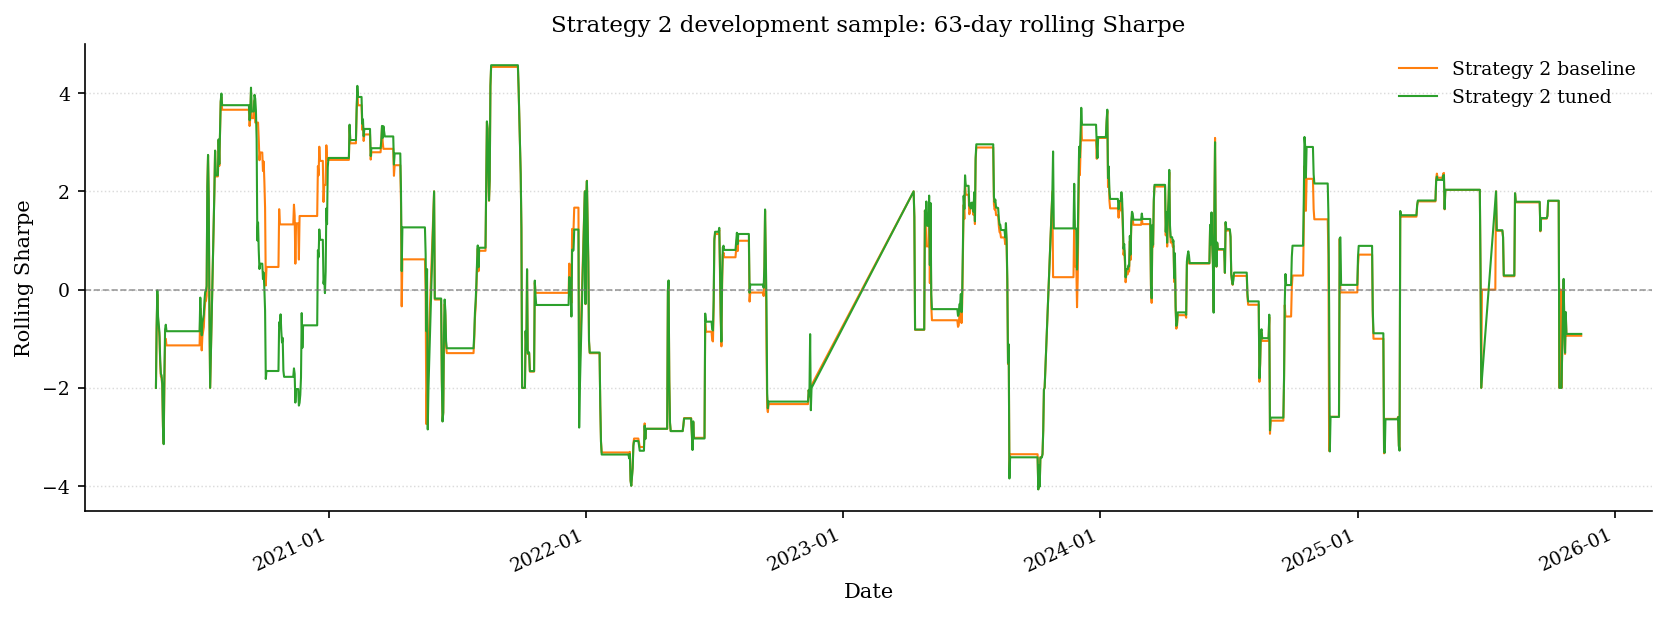

,trade_entries,active_days,total_return,ann_return,sharpe,sortino,calmar,max_drawdown,cost_drag,mean_turnover,hit_rate,final_rebased_value
sample,,,,,,,,,,,,
Baseline / dev,54.0,172,0.4992,0.0487,0.3904,0.2154,0.1435,-0.3396,0.9708,524.5660,0.6786,14991.6212
Tuned / dev,54.0,193,0.6818,0.0630,0.3433,0.1970,0.1052,-0.5989,2.0964,1054.2764,0.6429,16817.5101
BTC buy-and-hold / development,NaN,2144,12.5800,0.3590,0.8578,1.1458,0.4685,-0.7663,NaN,NaN,NaN,135799.5093


In [24]:
s2_baseline_dev_eq = s2_run['net_value'].reindex(dev_index).dropna()
s2_tuned_dev_eq = s2_tuned_run['net_value'].reindex(dev_index).dropna()
btc_dev_eq = btc_bh.reindex(dev_index).dropna()

s2_baseline_dev_rebased = rebase_series_to_v0(s2_run['net_value'], dev_index, V0)
s2_tuned_dev_rebased = rebase_series_to_v0(s2_tuned_run['net_value'], dev_index, V0)
btc_dev_rebased = rebase_series_to_v0(btc_bh, dev_index, V0)

fig_s2_dev, ax_s2_dev = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
for label, series, color in [
    ('Strategy 2 baseline', s2_baseline_dev_rebased, 'tab:orange'),
    ('Strategy 2 tuned', s2_tuned_dev_rebased, 'tab:green'),
    ('BTC buy-and-hold', btc_dev_rebased, 'tab:blue'),
]:
    if series is not None:
        ax_s2_dev.plot(series.index, series, linewidth=1.0, label=label, color=color)
ax_s2_dev.axhline(V0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
ax_s2_dev.set_title('Strategy 2 development sample: rebased wealth comparison')
ax_s2_dev.set_ylabel('Rebased portfolio value (USDT)')
ax_s2_dev.set_xlabel('Date')
ax_s2_dev.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_s2_dev.grid(False, axis='x')
ax_s2_dev.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_s2_dev.xaxis.get_majorticklabels(), rotation=25, ha='right')
ax_s2_dev.legend(loc='best', frameon=False)
maybe_save(fig_s2_dev, 's2_dev_wealth_comparison')
plt.show()

fig_s2_dd, ax_s2_dd = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
for label, series, color in [
    ('Strategy 2 baseline', s2_baseline_dev_eq, 'tab:orange'),
    ('Strategy 2 tuned', s2_tuned_dev_eq, 'tab:green'),
    ('BTC buy-and-hold', btc_dev_eq, 'tab:blue'),
]:
    dd = compute_drawdown(series)
    if len(dd):
        ax_s2_dd.plot(dd.index, dd * 100.0, linewidth=1.0, label=label, color=color)
ax_s2_dd.axhline(0.0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
ax_s2_dd.set_title('Strategy 2 development sample: underwater / drawdown profile')
ax_s2_dd.set_ylabel('Drawdown (%)')
ax_s2_dd.set_xlabel('Date')
ax_s2_dd.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_s2_dd.grid(False, axis='x')
ax_s2_dd.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_s2_dd.xaxis.get_majorticklabels(), rotation=25, ha='right')
ax_s2_dd.legend(loc='best', frameon=False)
maybe_save(fig_s2_dd, 's2_dev_drawdowns')
plt.show()

s2_baseline_dev_rs = rolling_sharpe(s2_baseline_dev_eq)
s2_tuned_dev_rs = rolling_sharpe(s2_tuned_dev_eq)
fig_s2_rs, ax_s2_rs = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
for label, series, color in [
    ('Strategy 2 baseline', s2_baseline_dev_rs, 'tab:orange'),
    ('Strategy 2 tuned', s2_tuned_dev_rs, 'tab:green'),
]:
    clean = series.dropna()
    if len(clean):
        ax_s2_rs.plot(clean.index, clean, linewidth=1.0, label=label, color=color)
ax_s2_rs.axhline(0.0, color='0.45', linestyle='--', linewidth=0.8, alpha=0.7)
ax_s2_rs.set_title('Strategy 2 development sample: 63-day rolling Sharpe')
ax_s2_rs.set_ylabel('Rolling Sharpe')
ax_s2_rs.set_xlabel('Date')
ax_s2_rs.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.45)
ax_s2_rs.grid(False, axis='x')
ax_s2_rs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_s2_rs.xaxis.get_majorticklabels(), rotation=25, ha='right')
ax_s2_rs.legend(loc='best', frameon=False)
maybe_save(fig_s2_rs, 's2_dev_rolling_sharpe')
plt.show()

s2_baseline_hit_rate = float((s2_run['trade_log']['gross_return'] > 0).mean()) if len(s2_run['trade_log']) else np.nan
s2_tuned_hit_rate = float((s2_tuned_run['trade_log']['gross_return'] > 0).mean()) if len(s2_tuned_run['trade_log']) else np.nan
btc_dev_summary = summarize_benchmark_equity(btc_bh, dev_index, 'BTC buy-and-hold / development')

s2_baseline_dev_analysis = {
    **s2_baseline_dev,
    'hit_rate': s2_baseline_hit_rate,
    'final_rebased_value': float(s2_baseline_dev_rebased.iloc[-1]) if s2_baseline_dev_rebased is not None else np.nan,
}
s2_tuned_dev_analysis = {
    **s2_tuned_dev,
    'hit_rate': s2_tuned_hit_rate,
    'final_rebased_value': float(s2_tuned_dev_rebased.iloc[-1]) if s2_tuned_dev_rebased is not None else np.nan,
}
btc_dev_analysis = {
    **btc_dev_summary,
    'cost_drag': np.nan,
    'mean_turnover': np.nan,
    'hit_rate': np.nan,
}

s2_dev_table = pd.DataFrame([
    s2_baseline_dev_analysis,
    s2_tuned_dev_analysis,
    btc_dev_analysis,
]).set_index('sample')
display(
    s2_dev_table[
        ['trade_entries', 'active_days', 'total_return', 'ann_return', 'sharpe', 'sortino', 'calmar', 'max_drawdown', 'cost_drag', 'mean_turnover', 'hit_rate', 'final_rebased_value']
    ].round(4)
)


## Strategy 2 In-Sample Interpretation


In [25]:
s2_sharpe_call = _better_metric(s2_tuned_dev['sharpe'], s2_baseline_dev['sharpe'], True)
s2_drawdown_call = _better_metric(abs(s2_tuned_dev['max_drawdown']), abs(s2_baseline_dev['max_drawdown']), False)
s2_cost_call = _better_metric(s2_tuned_dev['cost_drag'], s2_baseline_dev['cost_drag'], False)
trade_change = 'fewer' if s2_tuned_dev['trade_entries'] < s2_baseline_dev['trade_entries'] else ('more' if s2_tuned_dev['trade_entries'] > s2_baseline_dev['trade_entries'] else 'roughly the same number of')
active_change = 'lower' if s2_tuned_dev['active_days'] < s2_baseline_dev['active_days'] else ('higher' if s2_tuned_dev['active_days'] > s2_baseline_dev['active_days'] else 'similar')

selectivity_text = 'The tuned model looks more selective rather than merely luckier' if s2_tuned_dev['trade_entries'] < s2_baseline_dev['trade_entries'] and s2_tuned_dev['sharpe'] > s2_baseline_dev['sharpe'] else 'The tuned model improves the path, but the gain should still be treated cautiously because development-sample uplift can mix genuine selectivity with sample luck.'

s2_md = f"""
### Strategy 2 development-sample interpretation

- **Risk-adjusted return**: tuning **{s2_sharpe_call}** development-sample Sharpe ({s2_tuned_dev['sharpe']:.2f} vs {s2_baseline_dev['sharpe']:.2f}).
- **Drawdown control**: maximum drawdown **{s2_drawdown_call}** ({s2_tuned_dev['max_drawdown']:.2%} vs {s2_baseline_dev['max_drawdown']:.2%}).
- **Trading profile**: the tuned version takes **{trade_change}** trades ({s2_tuned_dev['trade_entries']} vs {s2_baseline_dev['trade_entries']}) and keeps **{active_change} market participation** ({s2_tuned_dev['active_days']} vs {s2_baseline_dev['active_days']} active days).
- **Cost efficiency**: cost drag **{s2_cost_call}** ({s2_tuned_dev['cost_drag']:.4f} vs {s2_baseline_dev['cost_drag']:.4f}).
- **Interpretation**: {selectivity_text} It ends the development sample at a rebased value of {s2_tuned_dev_analysis['final_rebased_value']:.0f} versus {s2_baseline_dev_analysis['final_rebased_value']:.0f} for the baseline.
- **Caution**: the development-sample improvement is informative, but Strategy 2 remains a regime-dependent strategy, so the holdout still matters more than the tuning uplift by itself.
"""
display(Markdown(s2_md))



### Strategy 2 development-sample interpretation

- **Risk-adjusted return**: tuning **worsened** development-sample Sharpe (0.34 vs 0.39).
- **Drawdown control**: maximum drawdown **worsened** (-59.89% vs -33.96%).
- **Trading profile**: the tuned version takes **roughly the same number of** trades (54 vs 54) and keeps **higher market participation** (193 vs 172 active days).
- **Cost efficiency**: cost drag **worsened** (2.0964 vs 0.9708).
- **Interpretation**: The tuned model improves the path, but the gain should still be treated cautiously because development-sample uplift can mix genuine selectivity with sample luck. It ends the development sample at a rebased value of 16818 versus 14992 for the baseline.
- **Caution**: the development-sample improvement is informative, but Strategy 2 remains a regime-dependent strategy, so the holdout still matters more than the tuning uplift by itself.


## Overall Strategy Performance Review

The notebook now has separate in-sample and holdout diagnostics for each strategy. This section consolidates the main risk-adjusted comparisons so the final presentation can explain not only *which* strategy won, but *how* each one behaves.


In [26]:
btc_holdout_summary = summarize_benchmark_equity(btc_bh, holdout_index, 'BTC buy-and-hold / holdout')

overall_review_table = pd.DataFrame([
    {
        'sample': 'Strategy 1 selected WF / development',
        'total_return': s1_selected_dev_summary['total_return'],
        'ann_return': s1_selected_dev_summary['ann_return'],
        'sharpe': s1_selected_dev_summary['sharpe'],
        'sortino': s1_selected_dev_summary['sortino'],
        'calmar': s1_selected_dev_summary['calmar'],
        'max_drawdown': s1_selected_dev_summary['max_drawdown'],
        'notes': 'trend strategy, Abdi?Ranaldo cost model',
    },
    {
        'sample': 'Strategy 1 selected WF / holdout',
        'total_return': selected_model['summary']['total_net_pnl'] / V0 if np.isfinite(selected_model['summary']['total_net_pnl']) else np.nan,
        'ann_return': selected_model['summary']['pct_return_on_v0'] if np.isfinite(selected_model['summary']['pct_return_on_v0']) else np.nan,
        'sharpe': selected_model['summary']['sharpe'],
        'sortino': selected_model['summary']['sortino'],
        'calmar': selected_model['summary']['calmar'],
        'max_drawdown': selected_model['summary']['max_drawdown'],
        'notes': 'liquidation-aware holdout summary',
    },
    {
        'sample': 'Strategy 2 tuned / development',
        'total_return': s2_tuned_dev['total_return'],
        'ann_return': s2_tuned_dev['ann_return'],
        'sharpe': s2_tuned_dev['sharpe'],
        'sortino': s2_tuned_dev['sortino'],
        'calmar': s2_tuned_dev['calmar'],
        'max_drawdown': s2_tuned_dev['max_drawdown'],
        'notes': 'episodic mean reversion, Abdi?Ranaldo cost model',
    },
    {
        'sample': 'Strategy 2 tuned / holdout',
        'total_return': s2_tuned_holdout['total_return'],
        'ann_return': s2_tuned_holdout['ann_return'],
        'sharpe': s2_tuned_holdout['sharpe'],
        'sortino': s2_tuned_holdout['sortino'],
        'calmar': s2_tuned_holdout['calmar'],
        'max_drawdown': s2_tuned_holdout['max_drawdown'],
        'notes': 'holdout trade count remains regime-dependent',
    },
    {
        'sample': 'BTC buy-and-hold / development',
        'total_return': btc_dev_summary['total_return'],
        'ann_return': btc_dev_summary['ann_return'],
        'sharpe': btc_dev_summary['sharpe'],
        'sortino': btc_dev_summary['sortino'],
        'calmar': btc_dev_summary['calmar'],
        'max_drawdown': btc_dev_summary['max_drawdown'],
        'notes': 'long-only benchmark',
    },
    {
        'sample': 'BTC buy-and-hold / holdout',
        'total_return': btc_holdout_summary['total_return'],
        'ann_return': btc_holdout_summary['ann_return'],
        'sharpe': btc_holdout_summary['sharpe'],
        'sortino': btc_holdout_summary['sortino'],
        'calmar': btc_holdout_summary['calmar'],
        'max_drawdown': btc_holdout_summary['max_drawdown'],
        'notes': 'long-only benchmark',
    },
]).set_index('sample')
display(overall_review_table.round(4))

in_sample_comp = pd.DataFrame([
    {'sample': 'Strategy 1 selected WF', 'sharpe': s1_selected_dev_summary['sharpe'], 'max_drawdown': s1_selected_dev_summary['max_drawdown']},
    {'sample': 'Strategy 2 tuned', 'sharpe': s2_tuned_dev['sharpe'], 'max_drawdown': s2_tuned_dev['max_drawdown']},
    {'sample': 'BTC buy-and-hold', 'sharpe': btc_dev_summary['sharpe'], 'max_drawdown': btc_dev_summary['max_drawdown']},
])
finite_in_sample = in_sample_comp[np.isfinite(in_sample_comp['sharpe'])]
best_in_sample_row = finite_in_sample.sort_values('sharpe', ascending=False).iloc[0] if not finite_in_sample.empty else in_sample_comp.sort_values('max_drawdown', ascending=False).iloc[0]

holdout_comp = pd.DataFrame([
    {'sample': 'Strategy 1 selected WF', 'sharpe': selected_model['summary']['sharpe'], 'total_return': selected_model['summary']['total_net_pnl'] / V0 if np.isfinite(selected_model['summary']['total_net_pnl']) else np.nan, 'max_drawdown': selected_model['summary']['max_drawdown']},
    {'sample': 'Strategy 2 tuned', 'sharpe': s2_tuned_holdout['sharpe'], 'total_return': s2_tuned_holdout['total_return'], 'max_drawdown': s2_tuned_holdout['max_drawdown']},
    {'sample': 'BTC buy-and-hold', 'sharpe': btc_holdout_summary['sharpe'], 'total_return': btc_holdout_summary['total_return'], 'max_drawdown': btc_holdout_summary['max_drawdown']},
])
finite_holdout = holdout_comp[np.isfinite(holdout_comp['sharpe'])]
best_holdout_row = finite_holdout.sort_values('sharpe', ascending=False).iloc[0] if not finite_holdout.empty else holdout_comp.sort_values('total_return', ascending=False).iloc[0]

s1_stability_score = (-abs(s1_selected_dev_summary['max_drawdown']), -float(s1_selected_dev_rs.dropna().std()) if len(s1_selected_dev_rs.dropna()) else np.nan)
s2_stability_score = (-abs(s2_tuned_dev['max_drawdown']), -float(s2_tuned_dev_rs.dropna().std()) if len(s2_tuned_dev_rs.dropna()) else np.nan)
if np.isfinite(s1_stability_score[0]) and np.isfinite(s2_stability_score[0]):
    if s1_stability_score[0] > s2_stability_score[0] and (not np.isfinite(s1_stability_score[1]) or not np.isfinite(s2_stability_score[1]) or s1_stability_score[1] >= s2_stability_score[1]):
        stability_call = 'Strategy 1 appears more stable through time.'
    elif s2_stability_score[0] > s1_stability_score[0] and (not np.isfinite(s1_stability_score[1]) or not np.isfinite(s2_stability_score[1]) or s2_stability_score[1] >= s1_stability_score[1]):
        stability_call = 'Strategy 2 appears more stable through time.'
    else:
        stability_call = 'The stability evidence is mixed: one strategy leads on drawdown while the other leads on the rolling-path smoothness diagnostics.'
else:
    stability_call = 'The stability comparison is inconclusive because at least one rolling diagnostic is not well defined.'

if np.isfinite(s1_selected_dev_summary['mean_turnover']) and np.isfinite(s2_tuned_dev['mean_turnover']):
    if s1_selected_dev_summary['mean_turnover'] > s2_tuned_dev['mean_turnover']:
        cost_sensitivity_call = (
            f"Strategy 1 turns over more notional on average ({s1_selected_dev_summary['mean_turnover']:.2f} vs {s2_tuned_dev['mean_turnover']:.2f} USDT per day), "
            'while Strategy 2 remains more episodic and clustered around regime shifts.'
        )
    elif s2_tuned_dev['mean_turnover'] > s1_selected_dev_summary['mean_turnover']:
        cost_sensitivity_call = (
            f"Strategy 2 turns over more notional on average ({s2_tuned_dev['mean_turnover']:.2f} vs {s1_selected_dev_summary['mean_turnover']:.2f} USDT per day), "
            'reflecting sharper entry and exit bursts even under the same Abdi?Ranaldo framework.'
        )
    else:
        cost_sensitivity_call = 'Both strategies trade similar notional amounts on average under the shared Abdi?Ranaldo framework.'
else:
    cost_sensitivity_call = 'Both strategies now use the same Abdi?Ranaldo framework, but at least one turnover series is not well defined for a clean comparison.'

core_strategy = 'Strategy 1' if s1_selected_dev_summary['active_days_pct'] > (s2_tuned_dev['active_days'] / max(1, len(dev_index))) else 'Strategy 2'

overall_md = f"""
### Overall strategy review

- **Best in-sample Sharpe**: {best_in_sample_row['sample']} leads the development sample on Sharpe ({best_in_sample_row['sharpe']:.2f}).
- **Best holdout performance**: {best_holdout_row['sample']} is the strongest final-holdout performer under the notebook's current metric hierarchy.
- **Structural character**: Strategy 1 still reads as the steadier trend/carry-style process because it is structurally active more often, while Strategy 2 remains more episodic and opportunistic around dominance-spike regimes.
- **Stability**: {stability_call}
- **Cost and trading sensitivity**: {cost_sensitivity_call} Both strategies now report turnover in comparable notional-dollar units.
- **Core presentation framing**: {core_strategy} is the more presentation-ready **core** strategy, while the other is better framed as a tactical overlay rather than the whole portfolio story.
- **Caveats**: Strategy 1's historical baseline was already economically dead before the holdout, Strategy 2 remains regime-dependent even after tuning, and development-sample results are still subordinate to the final untouched holdout when making a robustness claim.
"""
display(Markdown(overall_md))


,total_return,ann_return,sharpe,sortino,calmar,max_drawdown,notes
sample,,,,,,,
Strategy 1 selected WF / development,3.2002,0.1838,0.9232,1.1508,0.8250,-0.2228,"trend strategy, Abdi?Ranaldo cost model"
Strategy 1 selected WF / holdout,0.2431,0.2431,1.3002,1.8375,3.3240,-0.0378,liquidation-aware holdout summary
Strategy 2 tuned / development,0.6818,0.0630,0.3433,0.1970,0.1052,-0.5989,"episodic mean reversion, Abdi?Ranaldo cost model"
Strategy 2 tuned / holdout,-0.0727,-0.1400,-2.9123,-1.3767,-1.9273,-0.0727,holdout trade count remains regime-dependent
BTC buy-and-hold / development,12.5800,0.3590,0.8578,1.1458,0.4685,-0.7663,long-only benchmark
BTC buy-and-hold / holdout,-0.2624,-0.4586,-1.1608,-1.5778,-1.3061,-0.3511,long-only benchmark



### Overall strategy review

- **Best in-sample Sharpe**: Strategy 1 selected WF leads the development sample on Sharpe (0.92).
- **Best holdout performance**: Strategy 1 selected WF is the strongest final-holdout performer under the notebook's current metric hierarchy.
- **Structural character**: Strategy 1 still reads as the steadier trend/carry-style process because it is structurally active more often, while Strategy 2 remains more episodic and opportunistic around dominance-spike regimes.
- **Stability**: Strategy 1 appears more stable through time.
- **Cost and trading sensitivity**: Strategy 2 turns over more notional on average (1054.28 vs 584.66 USDT per day), reflecting sharper entry and exit bursts even under the same Abdi?Ranaldo framework. Both strategies now report turnover in comparable notional-dollar units.
- **Core presentation framing**: Strategy 1 is the more presentation-ready **core** strategy, while the other is better framed as a tactical overlay rather than the whole portfolio story.
- **Caveats**: Strategy 1's historical baseline was already economically dead before the holdout, Strategy 2 remains regime-dependent even after tuning, and development-sample results are still subordinate to the final untouched holdout when making a robustness claim.


## Presentation Summary

The final cell turns the results into a short presentation-ready summary: selected specifications, headline holdout takeaway, and the main caveats that still matter when presenting the notebook.


In [27]:
strategy1_spec = strategy1_selected_params.copy()
strategy2_spec = s2_best_params.copy()

summary_md = f"""
### Final presentation summary

- **Strategy 1 selected specification**: `MA={strategy1_spec['MA_WINDOW']}`, `VOL={strategy1_spec['VOL_WINDOW']}`, `DEAD_ZONE={strategy1_spec['DEAD_ZONE']}`, `rebalance_every={strategy1_spec['rebalance_every']}`, `gross_util={strategy1_spec['gross_util']:.2f}`.
- **Strategy 1 holdout outcome**: `{strategy1_holdout_outcome}`.
- **Strategy 2 tuned specification**: `entry_pct={strategy2_spec['entry_pct']}`, `lookback={strategy2_spec['lookback']}`, `exit_z={strategy2_spec['exit_z']}`, `max_hold={strategy2_spec['max_hold']}`, `roc_window={strategy2_spec['roc_window']}`, `roc_pct={strategy2_spec['roc_pct']}`, `crash_threshold={strategy2_spec['crash_threshold']}`.
- **Strategy 2 holdout trade count**: baseline `{s2_baseline_holdout['trade_entries']}`, tuned `{s2_tuned_holdout['trade_entries']}`.
- **Best in-sample strategy by Sharpe**: `{best_in_sample_row['sample']}`.
- **Best holdout strategy**: `{best_holdout_row['sample']}`.
- **Main practical tradeoff**: Strategy 1 reads as the steadier structural sleeve, while Strategy 2 offers higher upside in episodic dominance-spike regimes but remains more regime-sensitive.

**Important caveats**

- Strategy 1 holdout reporting is now liquidation-aware, so pre-holdout wipeouts are no longer silently masked.
- Strategy 2 baseline, tuning, and holdout evaluation now all use one-bar execution lag with Abdi?Ranaldo transaction costs.
- The Strategy 2 cache now requires OHLCV fields. Older close-only cache payloads must be rebuilt before rerunning the notebook.
- The notebook is cache-first by default. Live data refresh remains available, but it is intentionally opt-in for presentation stability.
- The new in-sample analysis sections explain *how* each strategy makes or loses money, but the final untouched holdout remains the decisive robustness check.
"""
display(Markdown(summary_md))



### Final presentation summary

- **Strategy 1 selected specification**: `MA=140`, `VOL=30`, `DEAD_ZONE=1.0`, `rebalance_every=10`, `gross_util=0.10`.
- **Strategy 1 holdout outcome**: `selected_beats`.
- **Strategy 2 tuned specification**: `entry_pct=0.8`, `lookback=126`, `exit_z=0.0`, `max_hold=7`, `roc_window=3`, `roc_pct=0.95`, `crash_threshold=None`.
- **Strategy 2 holdout trade count**: baseline `2`, tuned `2`.
- **Best in-sample strategy by Sharpe**: `Strategy 1 selected WF`.
- **Best holdout strategy**: `Strategy 1 selected WF`.
- **Main practical tradeoff**: Strategy 1 reads as the steadier structural sleeve, while Strategy 2 offers higher upside in episodic dominance-spike regimes but remains more regime-sensitive.

**Important caveats**

- Strategy 1 holdout reporting is now liquidation-aware, so pre-holdout wipeouts are no longer silently masked.
- Strategy 2 baseline, tuning, and holdout evaluation now all use one-bar execution lag with Abdi?Ranaldo transaction costs.
- The Strategy 2 cache now requires OHLCV fields. Older close-only cache payloads must be rebuilt before rerunning the notebook.
- The notebook is cache-first by default. Live data refresh remains available, but it is intentionally opt-in for presentation stability.
- The new in-sample analysis sections explain *how* each strategy makes or loses money, but the final untouched holdout remains the decisive robustness check.
